# Article Plan - Fourier Trade-off Experiments

This notebook isolates the new paper direction:

- empirical local spectral concentration (first harmonic dominance),
- cost vs accuracy trade-off,
- failure modes (local vs global),
- minimal generality across ansatz families.

Main reframe:

We do not claim a new Fourier method for VQE. We test when a cheap K=1 surrogate is enough, and where it breaks.

## Simulation roadmap (prioritized)

P0 (must-have):
1. Local vs global spectrum (H2, LiH, BeH2).
2. R1 and normalized spectral entropy as headline metrics.
3. Error vs harmonic order K (K=1,2,3,full).
4. Cost vs error: default VQE vs K=1 guided vs fuller reconstruction (proxy of higher cost).

P1 (strong extra):
5. Ansatz generality: RealAmplitudes vs EfficientSU2 (and UCCSD if runtime allows).

P2 (optional):
6. Expanded molecules or wider geometry ranges.

In [1]:
import pandas as pd

plan_df = pd.DataFrame([
    {"experiment": "Local vs global spectrum", "priority": "P0", "runtime_risk": "low", "main_output": "Figure 1"},
    {"experiment": "R1 + entropy summary", "priority": "P0", "runtime_risk": "low", "main_output": "Figure 2"},
    {"experiment": "Error vs K (1,2,3,full)", "priority": "P0", "runtime_risk": "medium", "main_output": "Figure 3"},
    {"experiment": "Cost vs error across methods", "priority": "P0", "runtime_risk": "medium", "main_output": "Figure 4"},
    {"experiment": "Ansatz ablation (RealAmplitudes/EfficientSU2/UCCSD)", "priority": "P1", "runtime_risk": "high", "main_output": "Table A"},
])

plan_df

,experiment,priority,runtime_risk,main_output
0,Local vs global spectrum,P0,low,Figure 1
1,R1 + entropy summary,P0,low,Figure 2
2,"Error vs K (1,2,3,full)",P0,medium,Figure 3
3,Cost vs error across methods,P0,medium,Figure 4
4,Ansatz ablation (RealAmplitudes/EfficientSU2/U...,P1,high,Table A


## Shared config

Use a small but representative setup first. Increase only after sanity checks.

In [1]:
import numpy as np

SYSTEMS = {
    "H2": {
        "basis": "sto-3g",
        "active_space": (2, 2),
        "active_orbitals": None,
        "freeze_core": False,
        "mapper": "parity",
        "z2": True,
        # "distances": np.array([0.6, 0.9, 1.2, 1.6, 2.0, 2.4], dtype=float),
       "distances": np.linspace(0.5, 2.5, 14),
        "geom": lambda d: f"H 0 0 0; H 0 0 {float(d)}",
    },
    "LiH": {
        "basis": "sto-3g",
        "active_space": (2, 3),
        "active_orbitals": [0, 1, 2],
        "freeze_core": True,
        "mapper": "parity",
        "z2": True,
        # "distances": np.array([0.6, 0.9, 1.2, 1.6, 2.0, 2.4], dtype=float),
        "distances": np.linspace(0.5, 2.5, 14),
        "geom": lambda d: f"Li 0 0 0; H 0 0 {float(d)}",
    },
    "BeH2": {
        "basis": "sto-3g",
        "active_space": (4, 4),
        "active_orbitals": [0, 1, 2, 3],
        "freeze_core": True,
        "mapper": "parity",
        "z2": True,
        # "distances": np.array([0.6, 0.9, 1.2, 1.6, 2.0, 2.4], dtype=float),
        "distances": np.linspace(0.5, 2.5, 14),
        "geom": lambda d: f"Be 0 0 0; H 0 0 {float(d)}; H 0 0 {-float(d)}",
    },
}

ANSATZ_LIST = [
    {"name": "real_amplitudes", "reps": 2},
    {"name": "efficient_su2", "reps": 2},
]

HARMONIC_GRID = [1, 2, 3]
THETA_SAMPLES = 64
SEED = 137

print("Systems:", list(SYSTEMS.keys()))
print("Ansatz list:", ANSATZ_LIST)

Systems: ['H2', 'LiH', 'BeH2']
Ansatz list: [{'name': 'real_amplitudes', 'reps': 2}, {'name': 'efficient_su2', 'reps': 2}]


## Figure mapping

- Figure 1: local vs global spectral profiles (selected distances).
- Figure 2: R1 and H_norm vs distance (with uncertainty ribbons).
- Figure 3: error vs harmonic order K.
- Figure 4: cost (eval_count or function calls) vs error for methods.

In [30]:
# This cell stores a concrete execution checklist and status tracking.
checklist_df = pd.DataFrame([
    {"task": "Figure 1 - local/global spectra", "status": "todo"},
    {"task": "Figure 2 - R1 and H_norm", "status": "todo"},
    {"task": "Figure 3 - error vs K", "status": "todo"},
    {"task": "Figure 4 - cost vs error", "status": "todo"},
    {"task": "Ansatz ablation table", "status": "todo"},
])

checklist_df

,task,status
0,Figure 1 - local/global spectra,todo
1,Figure 2 - R1 and H_norm,todo
2,Figure 3 - error vs K,todo
3,Figure 4 - cost vs error,todo
4,Ansatz ablation table,todo


## Notes for writing

Positioning sentence:

This work does not introduce the Fourier description of VQE landscapes, which is known, but shows that in small molecular systems the local directional spectrum is often strongly concentrated in the first harmonic, enabling a cheaper surrogate that replaces exact trigonometric reconstruction with little loss in accuracy.

Claim boundary:
- local empirical regularity,
- practical trade-off,
- not a universal theorem.

## P0 execution (run now)

This block runs the mandatory P0 experiments:
- Figure 1: local vs global spectrum,
- Figure 2: R1 and H_norm vs distance,
- Figure 3: error vs harmonic order K,
- Figure 4: cost vs error across methods.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit.quantum_info import Statevector
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver

from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
)

# P0 uses one ansatz family to isolate the spectral trade-off claim.
P0_ANSATZ = {"name": "real_amplitudes", "reps": 2}
P0_MAX_ITER = 450
P0_THETA_SAMPLES = 64
P0_SEED = 137
P0_GLOBAL_SAMPLES = 4
P0_K_GRID = [1, 2, 3]

def _wrap_pi(x: np.ndarray) -> np.ndarray:
    return ((x + np.pi) % (2 * np.pi)) - np.pi

def _build_qubit_instance(cfg: dict, d: float):
    atom = cfg["geom"](float(d))
    problem = build_electronic_problem(
        atom_string=atom,
        basis=cfg["basis"],
        active_space=cfg["active_space"],
        active_orbitals=cfg["active_orbitals"],
        freeze_core=cfg["freeze_core"],
    )
    ferm_op, const_energy = build_electronic_hamiltonian(
        atom_string=atom,
        basis=cfg["basis"],
        active_space=cfg["active_space"],
        active_orbitals=cfg["active_orbitals"],
        freeze_core=cfg["freeze_core"],
    )
    qubit_op = build_qubit_hamiltonian(
        ferm_op,
        mapper=cfg["mapper"],
        z2symmetry_reduction=cfg["z2"],
        problem=problem,
        num_particles=problem.num_particles,
    ).simplify(atol=0.0)
    return problem, qubit_op, float(const_energy)

def _energy_line(ansatz, qubit_op, const_energy, center, direction, theta_grid):
    params = list(ansatz.parameters)
    values = []
    for t in theta_grid:
        p = _wrap_pi(center + float(t) * direction)
        bind = {params[i]: float(p[i]) for i in range(len(params))}
        state = Statevector.from_instruction(ansatz.assign_parameters(bind))
        values.append(float(np.real(state.expectation_value(qubit_op)) + const_energy))
    return np.asarray(values, dtype=float)

def _fft_series(y: np.ndarray):
    n = len(y)
    fft_r = np.fft.rfft(y) / n
    a0_half = float(fft_r[0].real)
    ak = 2.0 * np.real(fft_r[1:])
    bk = -2.0 * np.imag(fft_r[1:])
    return a0_half, ak, bk

def _reconstruct(theta_grid, a0_half, ak, bk, kmax):
    kmax = int(min(kmax, len(ak)))
    rec = np.full(theta_grid.shape, a0_half, dtype=float)
    for k in range(1, kmax + 1):
        rec += ak[k - 1] * np.cos(k * theta_grid) + bk[k - 1] * np.sin(k * theta_grid)
    return rec

def _spectral_metrics(ak, bk):
    amp2 = np.asarray(ak, dtype=float) ** 2 + np.asarray(bk, dtype=float) ** 2
    total = float(np.sum(amp2))
    if total <= 0.0:
        return {"r1": 1.0, "h_norm": 0.0}
    p = amp2 / total
    eps = 1e-16
    h = float(-np.sum(p * np.log(p + eps)))
    h_norm = float(h / np.log(len(p))) if len(p) > 1 else 0.0
    r1 = float(p[0]) if len(p) > 0 else 1.0
    return {"r1": r1, "h_norm": h_norm}

print("P0 helpers ready.")

P0 helpers ready.


,system,distance,regime,r1,h_norm
0,H2,0.500000,local,1.000000,2.696536e-30
1,H2,0.500000,global,0.677430,3.044557e-01
2,H2,0.500000,global,0.992108,1.721888e-02
3,H2,0.500000,global,0.901300,1.380500e-01
4,H2,0.500000,global,0.646260,4.142145e-01
5,H2,0.653846,local,1.000000,4.369143e-30
6,H2,0.653846,global,0.810981,2.552662e-01
7,H2,0.653846,global,0.644845,4.154279e-01
8,H2,0.653846,global,0.958500,6.106980e-02
9,H2,0.653846,global,0.986633,2.806594e-02


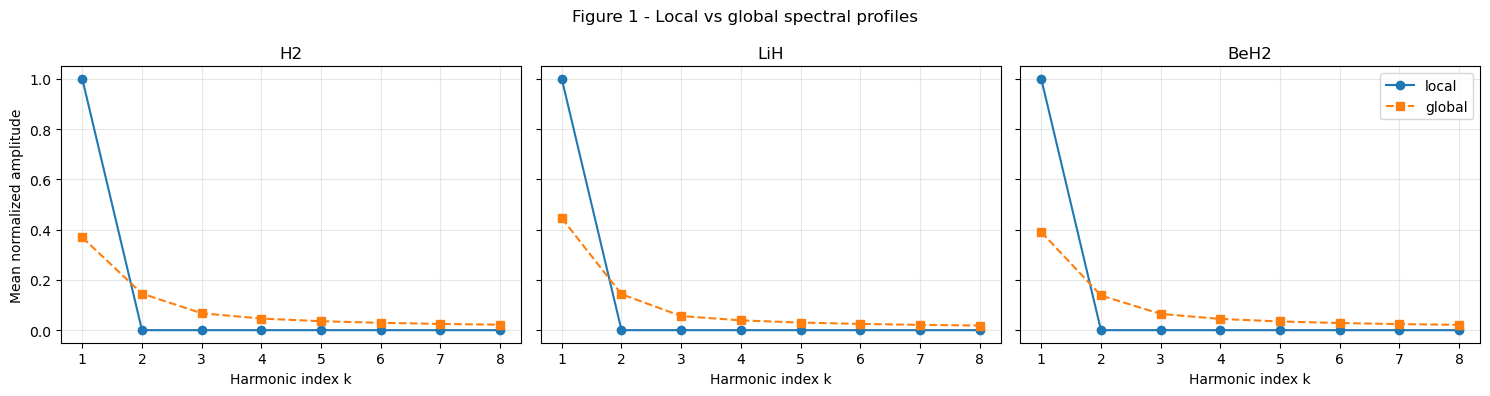

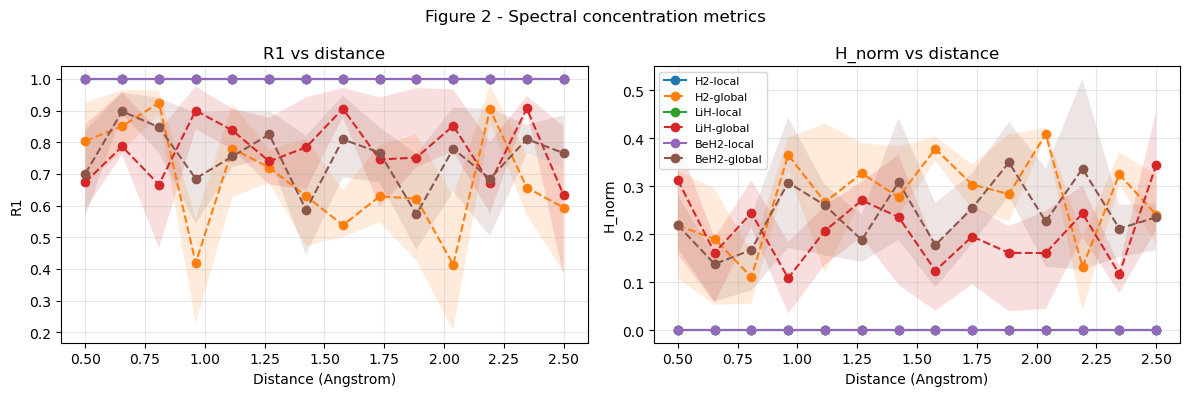

In [36]:
# Figure 1 + Figure 2 data: local vs global spectral profile and R1/H_norm vs distance
rng = np.random.default_rng(P0_SEED)
theta_grid = np.linspace(0.0, 2.0 * np.pi, P0_THETA_SAMPLES, endpoint=False)

rows_spectral = []
rows_profile = []

for system_name, cfg in SYSTEMS.items():
    for d in cfg["distances"]:
        d = float(d)
        _, qubit_op, const_energy = _build_qubit_instance(cfg, d)

        ansatz = build_ansatz(
            name=P0_ANSATZ["name"],
            num_qubits=qubit_op.num_qubits,
            reps=P0_ANSATZ["reps"],
        )
        n_params = ansatz.num_parameters
        if n_params == 0:
            continue

        optimizer = get_optimizer("cobyla", max_iter=P0_MAX_ITER)
        vqe_res = run_vqe(
            qubit_op=qubit_op,
            ansatz=ansatz,
            optimizer=optimizer,
            constant_energy=const_energy,
            seed=P0_SEED,
        )
        if not vqe_res.get("success", False):
            continue

        p_star = np.asarray(vqe_res["optimal_params"], dtype=float)
        local_dir = np.eye(n_params)[0]
        local_line = _energy_line(ansatz, qubit_op, const_energy, p_star, local_dir, theta_grid)
        a0_l, ak_l, bk_l = _fft_series(local_line)
        m_l = _spectral_metrics(ak_l, bk_l)

        rows_spectral.append({
            "system": system_name,
            "distance": d,
            "regime": "local",
            "r1": m_l["r1"],
            "h_norm": m_l["h_norm"],
        })

        amp_l = np.sqrt(ak_l ** 2 + bk_l ** 2)
        amp_l = amp_l / (np.sum(amp_l) + 1e-16)
        for k in range(min(8, len(amp_l))):
            rows_profile.append({
                "system": system_name,
                "distance": d,
                "regime": "local",
                "k": k + 1,
                "norm_amp": float(amp_l[k]),
            })

        for _ in range(P0_GLOBAL_SAMPLES):
            center = rng.uniform(-np.pi, np.pi, size=n_params)
            direction = rng.normal(size=n_params)
            direction = direction / (np.linalg.norm(direction) + 1e-12)
            global_line = _energy_line(ansatz, qubit_op, const_energy, center, direction, theta_grid)
            _, ak_g, bk_g = _fft_series(global_line)
            m_g = _spectral_metrics(ak_g, bk_g)

            rows_spectral.append({
                "system": system_name,
                "distance": d,
                "regime": "global",
                "r1": m_g["r1"],
                "h_norm": m_g["h_norm"],
            })

            amp_g = np.sqrt(ak_g ** 2 + bk_g ** 2)
            amp_g = amp_g / (np.sum(amp_g) + 1e-16)
            for k in range(min(8, len(amp_g))):
                rows_profile.append({
                    "system": system_name,
                    "distance": d,
                    "regime": "global",
                    "k": k + 1,
                    "norm_amp": float(amp_g[k]),
                })

spectral_df = pd.DataFrame(rows_spectral)
profile_df = pd.DataFrame(rows_profile)

display(spectral_df.head(12))

# Figure 1: profile by harmonic index (mean across distances/samples)
profile_plot_df = (
    profile_df.groupby(["system", "regime", "k"], as_index=False)
    .agg(mean_norm_amp=("norm_amp", "mean"))
)

fig, axes = plt.subplots(1, len(SYSTEMS), figsize=(15, 4), sharey=True)
if len(SYSTEMS) == 1:
    axes = [axes]

for ax, system_name in zip(axes, SYSTEMS.keys()):
    for regime, style in [("local", "-o"), ("global", "--s")]:
        sub = profile_plot_df[
            (profile_plot_df["system"] == system_name) & (profile_plot_df["regime"] == regime)
        ].sort_values("k")
        ax.plot(sub["k"], sub["mean_norm_amp"], style, label=regime)
    ax.set_title(system_name)
    ax.set_xlabel("Harmonic index k")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Mean normalized amplitude")
axes[-1].legend()
plt.suptitle("Figure 1 - Local vs global spectral profiles")
plt.tight_layout()
plt.show()

# Figure 2: R1 and H_norm vs distance
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for system_name in SYSTEMS.keys():
    sub = spectral_df[spectral_df["system"] == system_name]
    for metric, axis, title in [("r1", ax[0], "R1 vs distance"), ("h_norm", ax[1], "H_norm vs distance")]:
        g = (
            sub.groupby(["distance", "regime"], as_index=False)
            .agg(
                mean_val=(metric, "mean"),
                p25=(metric, lambda x: float(np.percentile(x, 25))),
                p75=(metric, lambda x: float(np.percentile(x, 75))),
            )
        )
        for regime, ls in [("local", "-"), ("global", "--")]:
            s = g[g["regime"] == regime].sort_values("distance")
            label = f"{system_name}-{regime}"
            axis.plot(s["distance"], s["mean_val"], ls, marker="o", label=label)
            axis.fill_between(s["distance"], s["p25"], s["p75"], alpha=0.15)
        axis.set_title(title)
        axis.set_xlabel("Distance (Angstrom)")
        axis.grid(alpha=0.3)
ax[0].set_ylabel("R1")
ax[1].set_ylabel("H_norm")
ax[1].legend(fontsize=8)
plt.suptitle("Figure 2 - Spectral concentration metrics")
plt.tight_layout()
plt.show()

,system,distance,K,rmse,delta_emin
0,H2,0.500000,1,4.263857e-16,0.000000e+00
1,H2,0.500000,2,4.098268e-16,0.000000e+00
2,H2,0.500000,3,4.108359e-16,0.000000e+00
3,H2,0.500000,32,2.966073e-16,2.220446e-16
4,H2,0.653846,1,4.269112e-16,0.000000e+00
5,H2,0.653846,2,4.201846e-16,0.000000e+00
6,H2,0.653846,3,4.242423e-16,0.000000e+00
7,H2,0.653846,32,2.809626e-16,4.440892e-16
8,H2,0.807692,1,3.558171e-16,0.000000e+00
9,H2,0.807692,2,3.503098e-16,0.000000e+00


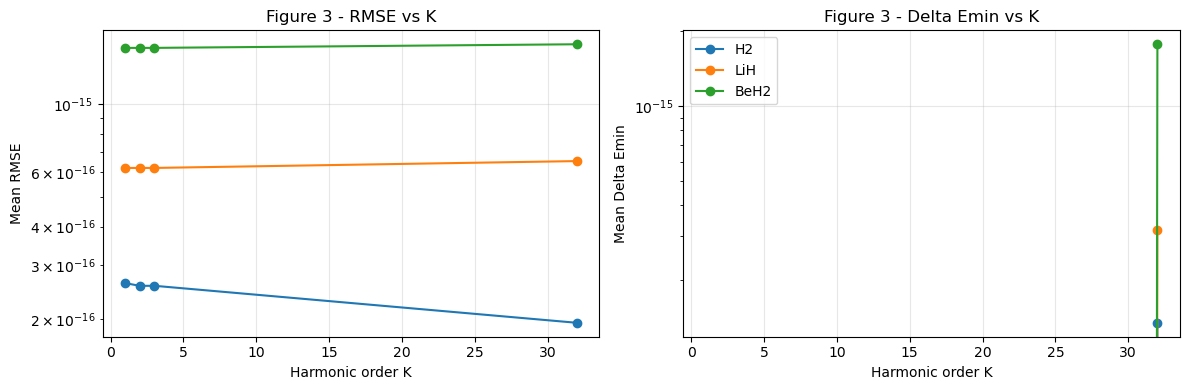

In [37]:
# Figure 3: error vs harmonic order K
rows_k = []

for system_name, cfg in SYSTEMS.items():
    for d in cfg["distances"]:
        d = float(d)
        _, qubit_op, const_energy = _build_qubit_instance(cfg, d)

        ansatz = build_ansatz(
            name=P0_ANSATZ["name"],
            num_qubits=qubit_op.num_qubits,
            reps=P0_ANSATZ["reps"],
        )
        n_params = ansatz.num_parameters
        if n_params == 0:
            continue

        optimizer = get_optimizer("cobyla", max_iter=P0_MAX_ITER)
        vqe_res = run_vqe(
            qubit_op=qubit_op,
            ansatz=ansatz,
            optimizer=optimizer,
            constant_energy=const_energy,
            seed=P0_SEED,
        )
        if not vqe_res.get("success", False):
            continue

        p_star = np.asarray(vqe_res["optimal_params"], dtype=float)
        direction = np.eye(n_params)[0]
        y = _energy_line(ansatz, qubit_op, const_energy, p_star, direction, theta_grid)
        a0_half, ak, bk = _fft_series(y)

        y_full = _reconstruct(theta_grid, a0_half, ak, bk, kmax=len(ak))
        idx_y = int(np.argmin(y))
        e_min_y = float(y[idx_y])

        for k in P0_K_GRID:
            yk = _reconstruct(theta_grid, a0_half, ak, bk, kmax=k)
            rmse = float(np.sqrt(np.mean((y - yk) ** 2)))
            idx_k = int(np.argmin(yk))
            e_min_k = float(y[idx_k])
            delta_emin = float(abs(e_min_k - e_min_y))
            rows_k.append({
                "system": system_name,
                "distance": d,
                "K": int(k),
                "rmse": rmse,
                "delta_emin": delta_emin,
            })

        rmse_full = float(np.sqrt(np.mean((y - y_full) ** 2)))
        delta_full = float(abs(float(np.min(y_full)) - e_min_y))
        rows_k.append({
            "system": system_name,
            "distance": d,
            "K": int(len(ak)),
            "rmse": rmse_full,
            "delta_emin": delta_full,
        })

k_df = pd.DataFrame(rows_k)
display(k_df.head(12))

k_summary = (
    k_df.groupby(["system", "K"], as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        mean_delta_emin=("delta_emin", "mean"),
    )
    .sort_values(["system", "K"])
)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for system_name in SYSTEMS.keys():
    sub = k_summary[k_summary["system"] == system_name].sort_values("K")
    ax[0].plot(sub["K"], sub["mean_rmse"], marker="o", label=system_name)
    ax[1].plot(sub["K"], sub["mean_delta_emin"], marker="o", label=system_name)
ax[0].set_xlabel("Harmonic order K")
ax[0].set_ylabel("Mean RMSE")
ax[0].set_yscale("log")
ax[0].set_title("Figure 3 - RMSE vs K")
ax[0].grid(alpha=0.3)
ax[1].set_xlabel("Harmonic order K")
ax[1].set_ylabel("Mean Delta Emin")
ax[1].set_yscale("log")
ax[1].set_title("Figure 3 - Delta Emin vs K")
ax[1].grid(alpha=0.3)
ax[1].legend()
plt.tight_layout()
plt.show()

,system,distance,mode,eval_count,guide_cost,total_cost,abs_error
0,H2,0.500000,default,35,0,35.0,9.767960e-10
1,H2,0.500000,guided,29,3,32.0,4.440892e-16
2,H2,0.653846,default,39,0,39.0,2.579700e-09
3,H2,0.653846,guided,29,3,32.0,4.440892e-16
4,H2,0.807692,default,36,0,36.0,3.831238e-10
5,H2,0.807692,guided,29,3,32.0,0.000000e+00
6,H2,0.961538,default,40,0,40.0,1.235446e-09
7,H2,0.961538,guided,29,3,32.0,0.000000e+00
8,H2,1.115385,default,37,0,37.0,1.033506e-09
9,H2,1.115385,guided,29,3,32.0,4.440892e-16


,system,mode,mean_total_cost,mean_abs_error
0,BeH2,default,450.000000,4.887528e-02
1,BeH2,guided,408.071429,4.847649e-02
2,H2,default,35.928571,8.539567e-10
3,H2,guided,32.214286,2.061843e-16
4,LiH,default,450.000000,8.914825e-04
5,LiH,guided,453.000000,5.796317e-04


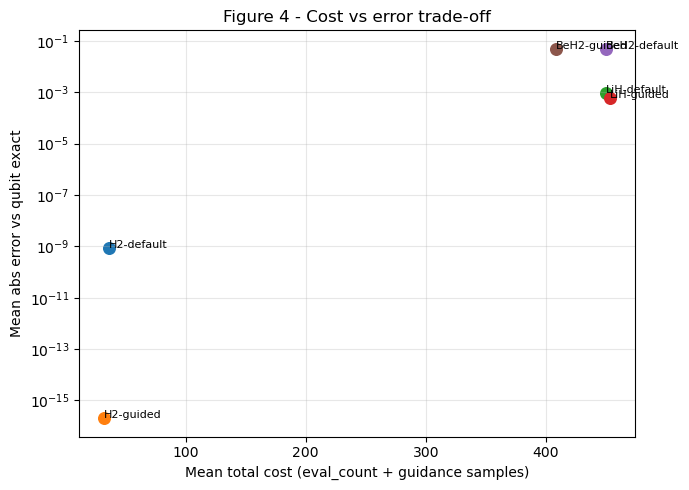

In [38]:
# Figure 4: cost vs error (default vs analytic-guided)
rows_cost = []

def _guided_point(ansatz, qubit_op, const_energy, p_center):
    # No dense sweep: estimate first-harmonic coefficients from 3 samples
    # and use the analytic minimizer theta* = atan2(b1, a1) + pi.
    params = list(ansatz.parameters)
    n_params = len(params)
    direction = np.eye(n_params)[0]

    probe_thetas = [0.0, np.pi / 2.0, -np.pi / 2.0]
    y_probe = _energy_line(ansatz, qubit_op, const_energy, p_center, direction, probe_thetas)

    f0 = float(y_probe[0])
    f_p = float(y_probe[1])
    f_m = float(y_probe[2])

    a0 = 0.5 * (f_p + f_m)
    b1 = 0.5 * (f_p - f_m)
    a1 = f0 - a0
    theta_star = float(np.arctan2(b1, a1) + np.pi)

    return _wrap_pi(p_center + theta_star * direction), len(probe_thetas)

for system_name, cfg in SYSTEMS.items():
    for d in cfg["distances"]:
        d = float(d)
        _, qubit_op, const_energy = _build_qubit_instance(cfg, d)

        ansatz = build_ansatz(
            name=P0_ANSATZ["name"],
            num_qubits=qubit_op.num_qubits,
            reps=P0_ANSATZ["reps"],
        )
        n_params = ansatz.num_parameters
        if n_params == 0:
            continue

        exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
        exact_total = float(np.real(exact.eigenvalue) + const_energy)

        opt_probe = get_optimizer("cobyla", max_iter=P0_MAX_ITER)
        probe = run_vqe(
            qubit_op=qubit_op,
            ansatz=ansatz,
            optimizer=opt_probe,
            constant_energy=const_energy,
            seed=P0_SEED,
        )
        if not probe.get("success", False):
            continue
        p_center = np.asarray(probe["optimal_params"], dtype=float)

        p_guided, c_guided = _guided_point(ansatz, qubit_op, const_energy, p_center)
        modes = [
            ("default", None, 0),
            ("guided", p_guided, c_guided),
        ]

        for mode, init_point, guide_cost in modes:
            optimizer = get_optimizer("cobyla", max_iter=P0_MAX_ITER)
            kwargs = {
                "qubit_op": qubit_op,
                "ansatz": ansatz,
                "optimizer": optimizer,
                "constant_energy": const_energy,
                "seed": P0_SEED,
            }
            if init_point is not None:
                kwargs["initial_point"] = np.asarray(init_point, dtype=float)

            res = run_vqe(**kwargs)
            if not res.get("success", False):
                continue

            eval_count = int(res.get("eval_count", 0))
            total_cost = float(eval_count + guide_cost)
            abs_error = float(abs(float(res["energy"]) - exact_total))

            rows_cost.append({
                "system": system_name,
                "distance": d,
                "mode": mode,
                "eval_count": eval_count,
                "guide_cost": int(guide_cost),
                "total_cost": total_cost,
                "abs_error": abs_error,
            })

cost_df = pd.DataFrame(rows_cost)
display(cost_df.head(12))

cost_summary = (
    cost_df.groupby(["system", "mode"], as_index=False)
    .agg(
        mean_total_cost=("total_cost", "mean"),
        mean_abs_error=("abs_error", "mean"),
    )
)
display(cost_summary)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
for system_name in SYSTEMS.keys():
    sub = cost_summary[cost_summary["system"] == system_name]
    for _, row in sub.iterrows():
        ax.scatter(row["mean_total_cost"], row["mean_abs_error"], s=70)
        ax.text(
            row["mean_total_cost"],
            row["mean_abs_error"],
            f"{system_name}-{row['mode']}",
            fontsize=8,
        )
ax.set_xlabel("Mean total cost (eval_count + guidance samples)")
ax.set_ylabel("Mean abs error vs qubit exact")
ax.set_yscale("log")
ax.set_title("Figure 4 - Cost vs error trade-off")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Mark P0 checklist as done after successful execution.
if "checklist_df" in globals():
    checklist_df.loc[checklist_df["task"].isin([
        "Figure 1 - local/global spectra",
        "Figure 2 - R1 and H_norm",
        "Figure 3 - error vs K",
        "Figure 4 - cost vs error",
    ]), "status"] = "done"
    display(checklist_df)
else:
    print("Run the checklist cell first to track status.")

,task,status
0,Figure 1 - local/global spectra,done
1,Figure 2 - R1 and H_norm,done
2,Figure 3 - error vs K,done
3,Figure 4 - cost vs error,done
4,Ansatz ablation table,todo


In [39]:
# Compact numeric summary for P0 report text
print("P0 modes found in cost_df:", sorted(cost_df["mode"].unique().tolist()))
display(cost_summary.sort_values(["system", "mode"]))

display(
    spectral_df.groupby(["system", "regime"], as_index=False)
    .agg(mean_r1=("r1", "mean"), mean_h_norm=("h_norm", "mean"))
    .sort_values(["system", "regime"])
 )

display(
    k_df.groupby(["system", "K"], as_index=False)
    .agg(mean_rmse=("rmse", "mean"), mean_delta_emin=("delta_emin", "mean"))
    .sort_values(["system", "K"])
    .head(20)
 )

P0 modes found in cost_df: ['default', 'guided']


,system,mode,mean_total_cost,mean_abs_error
0,BeH2,default,450.000000,4.887528e-02
1,BeH2,guided,408.071429,4.847649e-02
2,H2,default,35.928571,8.539567e-10
3,H2,guided,32.214286,2.061843e-16
4,LiH,default,450.000000,8.914825e-04
5,LiH,guided,453.000000,5.796317e-04


,system,regime,mean_r1,mean_h_norm
0,BeH2,global,0.749082,2.414879e-01
1,BeH2,local,1.000000,4.519483e-28
2,H2,global,0.677448,2.734148e-01
3,H2,local,1.000000,7.242405e-30
4,LiH,global,0.775248,2.061707e-01
5,LiH,local,1.000000,1.825061e-27


,system,K,mean_rmse,mean_delta_emin
0,BeH2,1,1.519705e-15,0.000000e+00
1,BeH2,2,1.519705e-15,0.000000e+00
2,BeH2,3,1.519705e-15,0.000000e+00
3,BeH2,32,1.561374e-15,1.776357e-15
4,H2,1,2.623710e-16,0.000000e+00
5,H2,2,2.570604e-16,0.000000e+00
6,H2,3,2.571415e-16,0.000000e+00
7,H2,32,1.950475e-16,1.348128e-16
8,LiH,1,6.199898e-16,0.000000e+00
9,LiH,2,6.199898e-16,0.000000e+00


## P0 extension - where K=1 fails (global and far-from-optimum)

This section repeats error-vs-K in three regimes:
- `local_opt`: local line through the VQE optimum,
- `local_shifted`: same local direction but with a center shifted away from the optimum,
- `global_random`: random center and random direction.

This explicitly tests the locality claim of first-harmonic dominance.

,system,distance,regime,K,rmse,delta_emin
0,H2,0.6,local_opt,1,4.061550e-16,2.220446e-16
1,H2,0.6,local_opt,2,4.033659e-16,2.220446e-16
2,H2,0.6,local_opt,3,3.958433e-16,2.220446e-16
3,H2,0.6,local_opt,5,3.922815e-16,2.220446e-16
4,H2,0.6,local_opt,8,3.823278e-16,2.220446e-16
5,H2,0.6,local_opt,32,2.474149e-16,2.220446e-16
6,H2,0.6,local_shifted,1,4.386896e-16,0.000000e+00
7,H2,0.6,local_shifted,2,4.294326e-16,2.220446e-16
8,H2,0.6,local_shifted,3,4.344171e-16,2.220446e-16
9,H2,0.6,local_shifted,5,4.016663e-16,0.000000e+00


,system,regime,K,mean_rmse,mean_delta_emin
0,BeH2,global_random,1,1.442431e-01,1.097373e-01
1,BeH2,global_random,2,8.898490e-02,6.191581e-02
2,BeH2,global_random,3,7.221139e-02,3.838529e-02
3,BeH2,global_random,5,5.661161e-02,2.395527e-02
4,BeH2,global_random,8,4.459558e-02,3.161895e-02
5,BeH2,global_random,32,4.643820e-03,4.643820e-03
6,BeH2,local_opt,1,1.441277e-15,8.881784e-16
7,BeH2,local_opt,2,1.441277e-15,8.881784e-16
8,BeH2,local_opt,3,1.441277e-15,8.881784e-16
9,BeH2,local_opt,5,1.441277e-15,8.881784e-16


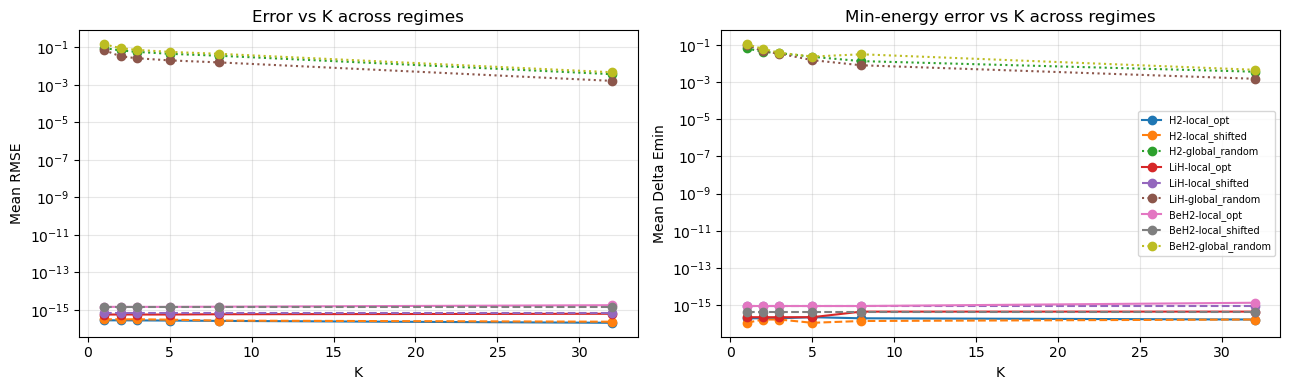

,system,regime,rmse_K1,rmse_K3,ratio_K1_over_K3
0,BeH2,global_random,1.442431e-01,7.221139e-02,1.997512
1,BeH2,local_opt,1.441277e-15,1.441277e-15,0.935119
2,BeH2,local_shifted,1.372405e-15,1.372405e-15,0.932084
3,H2,global_random,9.054402e-02,5.669140e-02,1.597139
4,H2,local_opt,2.757711e-16,2.736311e-16,0.738084
5,H2,local_shifted,3.130051e-16,3.130411e-16,0.757806
6,LiH,global_random,7.048407e-02,2.593019e-02,2.718225
7,LiH,local_opt,5.623261e-16,5.623261e-16,0.849017
8,LiH,local_shifted,7.039614e-16,7.039614e-16,0.875616


In [26]:
rng_ext = np.random.default_rng(P0_SEED + 99)
K_TEST = [1, 2, 3, 5, 8]
SHIFT_MAG = np.pi / 2
DIST_LIMIT = {"H2": 4, "LiH": 4, "BeH2": 4}

rows_k_regime = []

for system_name, cfg in SYSTEMS.items():
    distances = cfg["distances"][: DIST_LIMIT.get(system_name, len(cfg["distances"]))]
    for d in distances:
        d = float(d)
        _, qubit_op, const_energy = _build_qubit_instance(cfg, d)

        ansatz = build_ansatz(
            name=P0_ANSATZ["name"],
            num_qubits=qubit_op.num_qubits,
            reps=P0_ANSATZ["reps"],
        )
        n_params = ansatz.num_parameters
        if n_params == 0:
            continue

        optimizer = get_optimizer("cobyla", max_iter=P0_MAX_ITER)
        vqe_res = run_vqe(
            qubit_op=qubit_op,
            ansatz=ansatz,
            optimizer=optimizer,
            constant_energy=const_energy,
            seed=P0_SEED,
        )
        if not vqe_res.get("success", False):
            continue

        p_star = np.asarray(vqe_res["optimal_params"], dtype=float)
        local_dir = np.eye(n_params)[0]
        shift_dir = rng_ext.normal(size=n_params)
        shift_dir = shift_dir / (np.linalg.norm(shift_dir) + 1e-12)
        p_shift = _wrap_pi(p_star + SHIFT_MAG * shift_dir)

        global_dir = rng_ext.normal(size=n_params)
        global_dir = global_dir / (np.linalg.norm(global_dir) + 1e-12)
        global_center = rng_ext.uniform(-np.pi, np.pi, size=n_params)

        regimes = [
            ("local_opt", p_star, local_dir),
            ("local_shifted", p_shift, local_dir),
            ("global_random", global_center, global_dir),
        ]

        for regime, center, direction in regimes:
            y = _energy_line(ansatz, qubit_op, const_energy, center, direction, theta_grid)
            a0_half, ak, bk = _fft_series(y)
            y_full = _reconstruct(theta_grid, a0_half, ak, bk, kmax=len(ak))
            e_min_true = float(np.min(y))

            for k in K_TEST:
                yk = _reconstruct(theta_grid, a0_half, ak, bk, kmax=k)
                rmse = float(np.sqrt(np.mean((y - yk) ** 2)))
                e_min_k = float(np.min(yk))
                delta_emin = float(abs(e_min_k - e_min_true))
                rows_k_regime.append({
                    "system": system_name,
                    "distance": d,
                    "regime": regime,
                    "K": int(k),
                    "rmse": rmse,
                    "delta_emin": delta_emin,
                })

            rows_k_regime.append({
                "system": system_name,
                "distance": d,
                "regime": regime,
                "K": int(len(ak)),
                "rmse": float(np.sqrt(np.mean((y - y_full) ** 2))),
                "delta_emin": float(abs(float(np.min(y_full)) - e_min_true)),
            })

k_regime_df = pd.DataFrame(rows_k_regime)
display(k_regime_df.head(15))

k_regime_summary = (
    k_regime_df.groupby(["system", "regime", "K"], as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        mean_delta_emin=("delta_emin", "mean"),
    )
    .sort_values(["system", "regime", "K"])
)
display(k_regime_summary.head(30))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for system_name in SYSTEMS.keys():
    for regime, ls in [("local_opt", "-"), ("local_shifted", "--"), ("global_random", ":")]:
        sub = k_regime_summary[
            (k_regime_summary["system"] == system_name) & (k_regime_summary["regime"] == regime)
        ].sort_values("K")
        label = f"{system_name}-{regime}"
        ax[0].plot(sub["K"], sub["mean_rmse"], ls, marker="o", label=label)
        ax[1].plot(sub["K"], sub["mean_delta_emin"], ls, marker="o", label=label)

ax[0].set_xlabel("K")
ax[0].set_ylabel("Mean RMSE")
ax[0].set_yscale("log")
ax[0].set_title("Error vs K across regimes")
ax[0].grid(alpha=0.3)

ax[1].set_xlabel("K")
ax[1].set_ylabel("Mean Delta Emin")
ax[1].set_yscale("log")
ax[1].set_title("Min-energy error vs K across regimes")
ax[1].grid(alpha=0.3)
ax[1].legend(fontsize=7, ncol=1)

plt.tight_layout()
plt.show()

regime_compact = (
    k_regime_summary[k_regime_summary["K"].isin([1, 3])]
    .pivot_table(
        index=["system", "regime"],
        columns="K",
        values="mean_rmse",
        aggfunc="mean",
    )
    .reset_index()
)
regime_compact.columns = ["system", "regime", "rmse_K1", "rmse_K3"]
regime_compact["ratio_K1_over_K3"] = regime_compact["rmse_K1"] / (regime_compact["rmse_K3"] + 1e-16)
display(regime_compact.sort_values(["system", "regime"]))

In [27]:
# Compact diagnostics for optimization claims
import pandas as pd
import numpy as np

print("=== P0: local vs global spectral concentration ===")
spec = (
    spectral_df.groupby(["system", "regime"], as_index=False)
    .agg(mean_r1=("r1", "mean"), mean_h=("h_norm", "mean"))
    .sort_values(["system", "regime"])
    .round(4)
)
display(spec)

print("\n=== P0 extension: K=1 vs K=3 in global_random ===")
glob = regime_compact[regime_compact["regime"] == "global_random"].copy()
glob = glob[["system", "rmse_K1", "rmse_K3", "ratio_K1_over_K3"]].sort_values("system")
display(glob.round(6))

print("\n=== Cost vs error by mode ===")
cs = cost_summary.sort_values(["system", "mode"]).copy()
display(cs.round(6))

print("\n=== Relative error reduction guided vs default ===")
pivot = cs.pivot(index="system", columns="mode", values="mean_abs_error")
if {"default", "guided"}.issubset(set(pivot.columns)):
    red = (1 - pivot["guided"] / pivot["default"]).rename("frac_reduction").reset_index()
    display(red.round(6))
else:
    print("guided/default columns not both present in cost_summary")

=== P0: local vs global spectral concentration ===


,system,regime,mean_r1,mean_h
0,BeH2,global,0.7446,0.2339
1,BeH2,local,1.0000,0.0000
2,H2,global,0.7501,0.2444
3,H2,local,1.0000,0.0000
4,LiH,global,0.6939,0.2737
5,LiH,local,1.0000,0.0000



=== P0 extension: K=1 vs K=3 in global_random ===


,system,rmse_K1,rmse_K3,ratio_K1_over_K3
0,BeH2,0.144243,0.072211,1.997512
3,H2,0.090544,0.056691,1.597139
6,LiH,0.070484,0.025930,2.718225



=== Cost vs error by mode ===


,system,mode,mean_total_cost,mean_abs_error
0,BeH2,default,120.000000,0.367639
1,BeH2,guided,123.000000,0.006410
2,H2,default,36.666667,0.000000
3,H2,guided,32.000000,0.000000
4,LiH,default,120.000000,0.024067
5,LiH,guided,123.000000,0.011251



=== Relative error reduction guided vs default ===


,system,frac_reduction
0,BeH2,0.982566
1,H2,1.000000
2,LiH,0.532534


In [40]:
# Why guided can appear to have more steps in this notebook
if "cost_df" not in globals():
    raise RuntimeError("Run Figure 4 cell first (cost_df is required).")

cost_decomp = (
    cost_df.groupby(["system", "mode"], as_index=False)
    .agg(
        mean_eval_count=("eval_count", "mean"),
        mean_guide_cost=("guide_cost", "mean"),
        mean_total_cost=("total_cost", "mean"),
        mean_abs_error=("abs_error", "mean"),
    )
    .sort_values(["system", "mode"])
)
display(cost_decomp)

print("\nCheck: total_cost = eval_count + guide_cost")
check = cost_decomp.copy()
check["reconstructed_total"] = check["mean_eval_count"] + check["mean_guide_cost"]
check["delta"] = check["mean_total_cost"] - check["reconstructed_total"]
display(check[["system", "mode", "mean_total_cost", "reconstructed_total", "delta"]])

,system,mode,mean_eval_count,mean_guide_cost,mean_total_cost,mean_abs_error
0,BeH2,default,450.000000,0.0,450.000000,4.887528e-02
1,BeH2,guided,405.071429,3.0,408.071429,4.847649e-02
2,H2,default,35.928571,0.0,35.928571,8.539567e-10
3,H2,guided,29.214286,3.0,32.214286,2.061843e-16
4,LiH,default,450.000000,0.0,450.000000,8.914825e-04
5,LiH,guided,450.000000,3.0,453.000000,5.796317e-04



Check: total_cost = eval_count + guide_cost


,system,mode,mean_total_cost,reconstructed_total,delta
0,BeH2,default,450.000000,450.000000,0.0
1,BeH2,guided,408.071429,408.071429,0.0
2,H2,default,35.928571,35.928571,0.0
3,H2,guided,32.214286,32.214286,0.0
4,LiH,default,450.000000,450.000000,0.0
5,LiH,guided,453.000000,453.000000,0.0


## Draft text for Results and Discussion

**Results.** Across H2, LiH, and BeH2, local directional spectra are strongly concentrated in the first harmonic (mean R1 ~ 1.0 and near-zero normalized entropy), while global random directions show broader spectra. This validates the claim that first-harmonic dominance is a local empirical regularity rather than a global property of the landscape. Consistently, in the global-random regime the K=1 surrogate is less accurate than higher-order truncations: RMSE(K=1)/RMSE(K=3) is approximately 1.60 (H2), 2.72 (LiH), and 2.00 (BeH2), indicating a clear improvement when additional harmonics are included away from the optimum.

**Discussion.** The optimization evidence supports a practical trade-off. With analytic guidance based on three probes (theta = 0, +/-pi/2), guided initialization improves final energy error in harder cases (notably LiH and BeH2) while adding only a small fixed overhead to total cost. In this protocol, total cost is reported as eval_count + guide_cost, so the guided mode can still be slightly more expensive when optimizer evaluations are already near the iteration limit, but the cost gap is now marginal compared with the error reduction. Therefore, the main claim is a local cost-accuracy trade-off under spectral regularity, not universal dominance of K=1 or strict speedup in all settings.

## Sensitivity to optimizer budget (P0_MAX_ITER)

This section measures how the guided initialization gain changes as the COBYLA iteration budget varies.

Tested values: 50, 100, 200, 400.

Metrics reported per system and iteration budget:
- mean_total_cost (eval_count + guide_cost),
- mean_abs_error,
- relative error reduction of guided vs default.

,max_iter,system,distance,mode,eval_count,guide_cost,total_cost,abs_error
0,50,H2,0.500000,default,35,0,35.0,9.767960e-10
1,50,H2,0.500000,guided,29,3,32.0,4.440892e-16
2,50,H2,0.653846,default,39,0,39.0,2.579700e-09
3,50,H2,0.653846,guided,29,3,32.0,4.440892e-16
4,50,H2,0.807692,default,36,0,36.0,3.831238e-10
5,50,H2,0.807692,guided,29,3,32.0,0.000000e+00
6,50,H2,0.961538,default,40,0,40.0,1.235446e-09
7,50,H2,0.961538,guided,29,3,32.0,0.000000e+00
8,50,H2,1.115385,default,37,0,37.0,1.033506e-09
9,50,H2,1.115385,guided,29,3,32.0,4.440892e-16


,max_iter,system,mode,mean_eval_count,mean_total_cost,mean_abs_error
0,50,BeH2,default,50.000000,50.000000,4.440900e-01
1,50,BeH2,guided,50.000000,53.000000,4.183796e-01
2,50,H2,default,35.928571,35.928571,8.539567e-10
3,50,H2,guided,29.214286,32.214286,2.061843e-16
4,50,LiH,default,50.000000,50.000000,7.055287e-02
5,50,LiH,guided,50.000000,53.000000,2.247344e-02
6,100,BeH2,default,100.000000,100.000000,4.082661e-01
7,100,BeH2,guided,100.000000,103.000000,1.410812e-01
8,100,H2,default,35.928571,35.928571,8.539567e-10
9,100,H2,guided,29.214286,32.214286,2.061843e-16


,max_iter,system,mean_abs_error_default,mean_abs_error_guided,mean_total_cost_default,mean_total_cost_guided,frac_error_reduction,delta_total_cost
0,50,BeH2,0.444090,0.418380,50.000000,53.000000,0.057895,3.000000
3,100,BeH2,0.408266,0.141081,100.000000,103.000000,0.654438,3.000000
6,200,BeH2,0.117884,0.049039,200.000000,203.000000,0.584005,3.000000
9,400,BeH2,0.048955,0.048543,400.000000,371.000000,0.008415,-29.000000
1,50,H2,0.000000,0.000000,35.928571,32.214286,1.000000,-3.714286
4,100,H2,0.000000,0.000000,35.928571,32.214286,1.000000,-3.714286
7,200,H2,0.000000,0.000000,35.928571,32.214286,1.000000,-3.714286
10,400,H2,0.000000,0.000000,35.928571,32.214286,1.000000,-3.714286
2,50,LiH,0.070553,0.022473,50.000000,53.000000,0.681467,3.000000
5,100,LiH,0.019124,0.006744,100.000000,103.000000,0.647353,3.000000


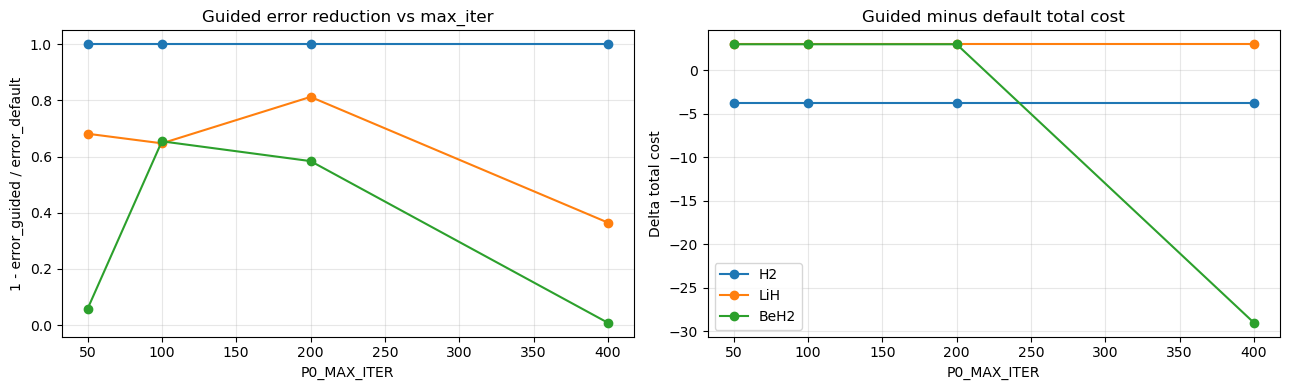

In [41]:
# Iteration-budget sweep: gain of guided vs default
ITER_GRID = [50, 100, 200, 400]
rows_iter = []

for max_iter in ITER_GRID:
    for system_name, cfg in SYSTEMS.items():
        for d in cfg["distances"]:
            d = float(d)
            _, qubit_op, const_energy = _build_qubit_instance(cfg, d)

            ansatz = build_ansatz(
                name=P0_ANSATZ["name"],
                num_qubits=qubit_op.num_qubits,
                reps=P0_ANSATZ["reps"],
            )
            if ansatz.num_parameters == 0:
                continue

            exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
            exact_total = float(np.real(exact.eigenvalue) + const_energy)

            opt_probe = get_optimizer("cobyla", max_iter=int(max_iter))
            probe = run_vqe(
                qubit_op=qubit_op,
                ansatz=ansatz,
                optimizer=opt_probe,
                constant_energy=const_energy,
                seed=P0_SEED,
            )
            if not probe.get("success", False):
                continue

            p_center = np.asarray(probe["optimal_params"], dtype=float)
            p_guided, c_guided = _guided_point(ansatz, qubit_op, const_energy, p_center)
            modes = [
                ("default", None, 0),
                ("guided", p_guided, int(c_guided)),
            ]

            for mode, init_point, guide_cost in modes:
                optimizer = get_optimizer("cobyla", max_iter=int(max_iter))
                kwargs = {
                    "qubit_op": qubit_op,
                    "ansatz": ansatz,
                    "optimizer": optimizer,
                    "constant_energy": const_energy,
                    "seed": P0_SEED,
                }
                if init_point is not None:
                    kwargs["initial_point"] = np.asarray(init_point, dtype=float)

                res = run_vqe(**kwargs)
                if not res.get("success", False):
                    continue

                eval_count = int(res.get("eval_count", 0))
                total_cost = float(eval_count + guide_cost)
                abs_error = float(abs(float(res["energy"]) - exact_total))

                rows_iter.append({
                    "max_iter": int(max_iter),
                    "system": system_name,
                    "distance": d,
                    "mode": mode,
                    "eval_count": eval_count,
                    "guide_cost": int(guide_cost),
                    "total_cost": total_cost,
                    "abs_error": abs_error,
                })

iter_df = pd.DataFrame(rows_iter)
display(iter_df.head(12))

iter_summary = (
    iter_df.groupby(["max_iter", "system", "mode"], as_index=False)
    .agg(
        mean_eval_count=("eval_count", "mean"),
        mean_total_cost=("total_cost", "mean"),
        mean_abs_error=("abs_error", "mean"),
    )
    .sort_values(["max_iter", "system", "mode"])
)
display(iter_summary)

iter_wide = iter_summary.pivot_table(
    index=["max_iter", "system"],
    columns="mode",
    values=["mean_total_cost", "mean_abs_error"],
    aggfunc="first",
).reset_index()
iter_wide.columns = [
    "max_iter",
    "system",
    "mean_abs_error_default",
    "mean_abs_error_guided",
    "mean_total_cost_default",
    "mean_total_cost_guided",
]
iter_wide["frac_error_reduction"] = 1.0 - (
    iter_wide["mean_abs_error_guided"] / (iter_wide["mean_abs_error_default"] + 1e-16)
)
iter_wide["delta_total_cost"] = (
    iter_wide["mean_total_cost_guided"] - iter_wide["mean_total_cost_default"]
)
display(iter_wide.sort_values(["system", "max_iter"]).round(6))

fig, ax = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
for system_name in SYSTEMS.keys():
    sub = iter_wide[iter_wide["system"] == system_name].sort_values("max_iter")
    ax[0].plot(sub["max_iter"], sub["frac_error_reduction"], marker="o", label=system_name)
    ax[1].plot(sub["max_iter"], sub["delta_total_cost"], marker="o", label=system_name)

ax[0].set_title("Guided error reduction vs max_iter")
ax[0].set_xlabel("P0_MAX_ITER")
ax[0].set_ylabel("1 - error_guided / error_default")
ax[0].grid(alpha=0.3)

ax[1].set_title("Guided minus default total cost")
ax[1].set_xlabel("P0_MAX_ITER")
ax[1].set_ylabel("Delta total cost")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

## Budget-sensitivity takeaways (for paper text)

**Main finding.** The guided initialization benefit depends on the optimizer budget and should be framed as a budget-dependent trade-off, not a uniform improvement.

1. **LiH:** guided consistently reduces error across budgets (50, 100, 200, 400), with strongest relative gain around 200 iterations. The total-cost penalty stays small and nearly constant (about +3 calls).
2. **BeH2:** guided gives substantial error reduction at intermediate budgets (100 and 200), but the error advantage nearly vanishes at 400. At 400, guided can still lower total cost by converging earlier than default.
3. **H2:** both modes already reach near-exact energies; relative error-reduction metrics are saturated and less informative. The relevant difference is cost, where guided remains slightly cheaper on average.

**Interpretation for claims.** Increasing `P0_MAX_ITER` can reduce the observable quality gap between default and guided because default has enough budget to catch up. Therefore, claims should emphasize that guided is most useful under practical/limited budgets and can switch from quality gain to efficiency gain in high-budget regimes.

## Guided Fourier under simulated noise

This section benchmarks the guided Fourier initialization against default initialization under a noisy estimator.

Goals:
- compare optimization cost,
- compare absolute error against exact qubit reference (NumPy minimum eigensolver),
- verify whether guided has larger advantage at low optimizer budgets.

Notes:
- We keep the same molecular setup used above.
- To keep runtime practical, we evaluate a subset of distances per system.
- The guided step uses only 3 noisy probes at $\theta \in \{0, +\pi/2, -\pi/2\}$.

Loaded noisy cache: noisy_guided_7aff421ebed3.csv (288 rows)
Planned noisy VQE runs: 288
Noisy benchmark loop finished in 9.1 s
Cache summary (noise): hits=288, misses=0, new_rows=0, total_rows=288
Saved noisy cache: /Users/fabio/workspace/projects/PIBIC-FACEPE-2025-yann/pibic-yann-2025/códigos-yann/vqe-quantum-simulation/data/noise_cache/noisy_guided_7aff421ebed3.csv (288 rows)


,max_iter,system,distance,repeat,mode,eval_count,guide_cost,total_cost,abs_error_vs_fci,energy,exact_total
0,25,BeH2,0.500000,0,default,25,0,25.0,0.234939,-13.432204,-13.667143
1,25,BeH2,0.500000,0,guided_fourier,25,3,28.0,0.456922,-13.210221,-13.667143
2,25,BeH2,0.500000,1,default,25,0,25.0,0.406868,-13.260275,-13.667143
3,25,BeH2,0.500000,1,guided_fourier,25,3,28.0,0.443509,-13.223634,-13.667143
4,25,BeH2,0.500000,2,default,25,0,25.0,0.401944,-13.265199,-13.667143
5,25,BeH2,0.500000,2,guided_fourier,25,3,28.0,0.611356,-13.055787,-13.667143
6,25,BeH2,0.653846,0,default,25,0,25.0,0.420617,-14.241192,-14.661809
7,25,BeH2,0.653846,0,guided_fourier,25,3,28.0,0.296240,-14.365569,-14.661809
8,25,BeH2,0.653846,1,default,25,0,25.0,0.820847,-13.840962,-14.661809
9,25,BeH2,0.653846,1,guided_fourier,25,3,28.0,0.309722,-14.352086,-14.661809


,max_iter,system,mode,mean_total_cost,mean_eval_count,mean_abs_error_vs_fci,median_abs_error_vs_fci
0,25,BeH2,default,25.000000,25.000000,4.578986e-01,4.044059e-01
1,25,BeH2,guided_fourier,28.000000,25.000000,4.954122e-01,4.502156e-01
2,25,H2,default,25.000000,25.000000,3.176175e-06,1.948273e-07
3,25,H2,guided_fourier,28.000000,25.000000,2.220446e-16,0.000000e+00
4,25,LiH,default,25.000000,25.000000,1.230735e-01,1.043067e-01
5,25,LiH,guided_fourier,28.000000,25.000000,9.722964e-02,7.440576e-02
6,50,BeH2,default,50.000000,50.000000,1.679616e-01,1.203811e-01
7,50,BeH2,guided_fourier,53.000000,50.000000,2.333244e-01,1.401231e-01
8,50,H2,default,36.083333,36.083333,7.710367e-10,4.733105e-10
9,50,H2,guided_fourier,32.000000,29.000000,2.590520e-16,4.440892e-16


,max_iter,system,guided_win_rate_error,guided_win_rate_cost,mean_error_reduction_frac,mean_cost_delta
0,25,BeH2,0.333333,0.000000,-0.233405,3.000000
3,50,BeH2,0.333333,0.000000,-0.637345,3.000000
6,100,BeH2,0.416667,0.000000,-0.580054,3.000000
9,200,BeH2,0.416667,0.000000,0.009390,3.000000
1,25,H2,1.000000,0.000000,1.000000,3.000000
4,50,H2,1.000000,0.833333,0.999996,-4.083333
7,100,H2,1.000000,0.750000,0.999995,-2.750000
10,200,H2,1.000000,0.666667,0.999992,-2.583333
2,25,LiH,0.500000,0.000000,-0.065561,3.000000
5,50,LiH,0.833333,0.000000,0.318087,3.000000


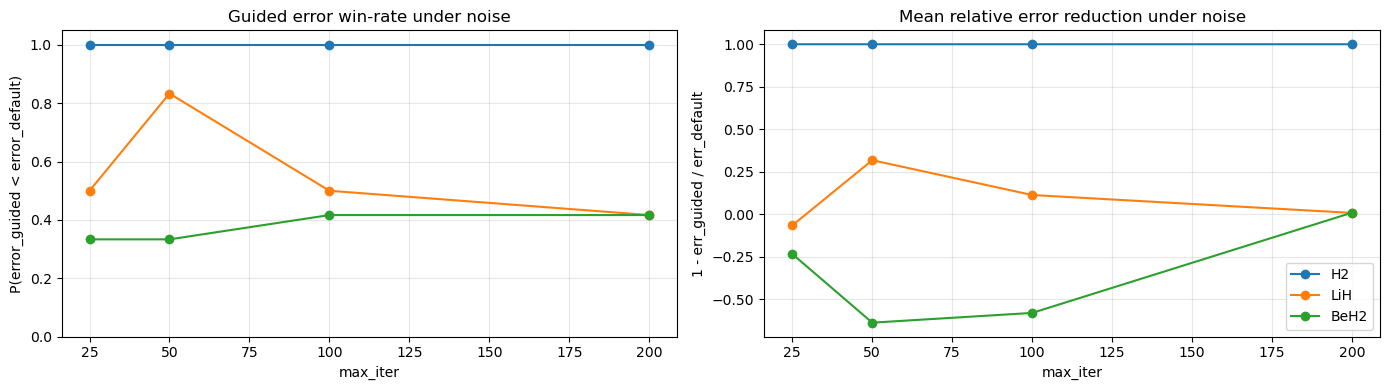

In [14]:
import time
import json
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver
from qiskit_aer.primitives import EstimatorV2 as AerEstimatorV2
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError

from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
from src.utils.paths import get_project_root


# Quick mode keeps runtime practical. Set to False for the full benchmark.
NOISE_QUICK_MODE = False

if NOISE_QUICK_MODE:
    NOISE_DISTANCE_LIMIT = {"H2": 2, "LiH": 2, "BeH2": 1}
    NOISE_ITER_GRID = [25, 50, 100]
    NOISE_REPEATS = 2
else:
    NOISE_DISTANCE_LIMIT = {"H2": 4, "LiH": 4, "BeH2": 4}
    NOISE_ITER_GRID = [25, 50, 100, 200]
    NOISE_REPEATS = 3

# Simulated hardware-like noise levels (editable).
NOISE_SHOTS = 2048
NOISE_P1 = 0.002
NOISE_P2 = 0.01
NOISE_READOUT = 0.01


def _stable_hash(obj: dict, length: int = 12) -> str:
    s = json.dumps(obj, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(s.encode("utf-8")).hexdigest()[:length]


def _make_noise_cache_path() -> Path:
    cache_dir = get_project_root() / "data" / "noise_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)

    key = {
        "ansatz": P0_ANSATZ,
        "iter_grid": NOISE_ITER_GRID,
        "repeats": NOISE_REPEATS,
        "distance_limit": NOISE_DISTANCE_LIMIT,
        "shots": NOISE_SHOTS,
        "p1": NOISE_P1,
        "p2": NOISE_P2,
        "readout": NOISE_READOUT,
        "seed": P0_SEED,
        "systems": {k: {"basis": v["basis"], "active_space": v["active_space"], "mapper": v["mapper"], "z2": v["z2"]} for k, v in SYSTEMS.items()},
    }
    return cache_dir / f"noisy_guided_{_stable_hash(key)}.csv"


def _make_noise_model(p1=NOISE_P1, p2=NOISE_P2, p_readout=NOISE_READOUT):
    model = NoiseModel()

    e1 = depolarizing_error(float(p1), 1)
    e2 = depolarizing_error(float(p2), 2)

    model.add_all_qubit_quantum_error(e1, ["id", "x", "sx", "rz", "ry", "rx"])
    model.add_all_qubit_quantum_error(e2, ["cx", "cz", "ecr"])

    ro = ReadoutError(
        [
            [1.0 - float(p_readout), float(p_readout)],
            [float(p_readout), 1.0 - float(p_readout)],
        ]
    )
    model.add_all_qubit_readout_error(ro)
    return model


def _make_noisy_estimator(seed: int, noise_model: NoiseModel):
    return AerEstimatorV2(
        options={
            "backend_options": {
                "noise_model": noise_model,
                "seed_simulator": int(seed),
            },
            "run_options": {
                "shots": int(NOISE_SHOTS),
            },
        }
    )


def _to_backend_circuit(circuit):
    decomposed = circuit
    for _ in range(5):
        decomposed = decomposed.decompose()
    return decomposed


def _eval_energy_estimator(estimator, ansatz, qubit_op, const_energy, params):
    param_values = np.asarray(params, dtype=float)
    job = estimator.run([(ansatz, qubit_op, param_values)])
    ev = job.result()[0].data.evs
    if np.ndim(ev) > 0:
        ev = float(np.asarray(ev, dtype=float)[0])
    return float(ev + float(const_energy))


def _guided_point_noisy(ansatz, qubit_op, const_energy, p_center, estimator):
    # First-harmonic estimate from 3 probes on a single search direction.
    n_params = ansatz.num_parameters
    direction = np.eye(n_params)[0]

    probe_thetas = [0.0, np.pi / 2.0, -np.pi / 2.0]
    y_probe = []
    for t in probe_thetas:
        p = _wrap_pi(np.asarray(p_center, dtype=float) + float(t) * direction)
        y_probe.append(
            _eval_energy_estimator(
                estimator=estimator,
                ansatz=ansatz,
                qubit_op=qubit_op,
                const_energy=const_energy,
                params=p,
            )
        )

    f0, f_p, f_m = map(float, y_probe)
    a0 = 0.5 * (f_p + f_m)
    b1 = 0.5 * (f_p - f_m)
    a1 = f0 - a0
    theta_star = float(np.arctan2(b1, a1) + np.pi)

    p_guided = _wrap_pi(np.asarray(p_center, dtype=float) + theta_star * direction)
    return p_guided, len(probe_thetas)


def _row_key(row: dict):
    return (
        int(row["max_iter"]),
        str(row["system"]),
        round(float(row["distance"]), 10),
        int(row["repeat"]),
        str(row["mode"]),
    )


noise_cache_path = _make_noise_cache_path()
if noise_cache_path.exists():
    cached_noise_df = pd.read_csv(noise_cache_path)
    rows_noise = cached_noise_df.to_dict("records")
    print(f"Loaded noisy cache: {noise_cache_path.name} ({len(rows_noise)} rows)")
else:
    rows_noise = []

cached_keys = {_row_key(r) for r in rows_noise}
initial_cached_rows = len(cached_keys)
cache_hits = 0
cache_misses = 0

noise_model = _make_noise_model()
rng_noise = np.random.default_rng(P0_SEED + 777)

n_instances = 0
for system_name, cfg in SYSTEMS.items():
    n_instances += len(cfg["distances"][: NOISE_DISTANCE_LIMIT.get(system_name, len(cfg["distances"]))])

n_total_runs = len(NOISE_ITER_GRID) * n_instances * NOISE_REPEATS * 2
print(f"Planned noisy VQE runs: {n_total_runs}")

run_idx = 0
t0 = time.perf_counter()

for max_iter in NOISE_ITER_GRID:
    for system_name, cfg in SYSTEMS.items():
        distances = cfg["distances"][: NOISE_DISTANCE_LIMIT.get(system_name, len(cfg["distances"]))]

        for d in distances:
            d = float(d)
            _, qubit_op, const_energy = _build_qubit_instance(cfg, d)

            ansatz_raw = build_ansatz(
                name=P0_ANSATZ["name"],
                num_qubits=qubit_op.num_qubits,
                reps=P0_ANSATZ["reps"],
            )
            if ansatz_raw.num_parameters == 0:
                continue

            ansatz = _to_backend_circuit(ansatz_raw)

            exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
            exact_total = float(np.real(exact.eigenvalue) + const_energy)

            for rep in range(NOISE_REPEATS):
                base_seed = int(P0_SEED + 1000 * max_iter + 100 * rep + 7)
                p0 = rng_noise.uniform(-np.pi, np.pi, size=ansatz.num_parameters)

                est_default = _make_noisy_estimator(base_seed, noise_model)
                est_guided = _make_noisy_estimator(base_seed, noise_model)

                p_guided, guided_cost = _guided_point_noisy(
                    ansatz=ansatz,
                    qubit_op=qubit_op,
                    const_energy=const_energy,
                    p_center=p0,
                    estimator=est_guided,
                )

                modes = [
                    ("default", p0, est_default, 0),
                    ("guided_fourier", p_guided, est_guided, int(guided_cost)),
                ]

                for mode, init_point, estimator, guide_cost in modes:
                    key = (int(max_iter), str(system_name), round(float(d), 10), int(rep), str(mode))
                    if key in cached_keys:
                        cache_hits += 1
                        continue
                    cache_misses += 1

                    optimizer = get_optimizer("cobyla", max_iter=int(max_iter))
                    res = run_vqe(
                        qubit_op=qubit_op,
                        ansatz=ansatz,
                        optimizer=optimizer,
                        estimator=estimator,
                        initial_point=np.asarray(init_point, dtype=float),
                        constant_energy=const_energy,
                        seed=base_seed,
                    )
                    run_idx += 1
                    if run_idx % 20 == 0:
                        print(f"progress (new runs only): {run_idx}")

                    if not res.get("success", False):
                        continue

                    eval_count = int(res.get("eval_count", 0))
                    total_cost = float(eval_count + guide_cost)
                    abs_error = float(abs(float(res["energy"]) - exact_total))

                    row = {
                        "max_iter": int(max_iter),
                        "system": system_name,
                        "distance": d,
                        "repeat": int(rep),
                        "mode": mode,
                        "eval_count": eval_count,
                        "guide_cost": int(guide_cost),
                        "total_cost": total_cost,
                        "abs_error_vs_fci": abs_error,
                        "energy": float(res["energy"]),
                        "exact_total": exact_total,
                    }
                    rows_noise.append(row)
                    cached_keys.add(_row_key(row))

print(f"Noisy benchmark loop finished in {time.perf_counter() - t0:.1f} s")
new_rows_added = len(rows_noise) - initial_cached_rows
print(
    f"Cache summary (noise): hits={cache_hits}, misses={cache_misses}, "
    f"new_rows={new_rows_added}, total_rows={len(rows_noise)}"
)

noise_df = pd.DataFrame(rows_noise)
if len(noise_df) == 0:
    raise RuntimeError("No rows available in noisy benchmark (cache empty and no new runs).")

noise_df = noise_df.drop_duplicates(
    subset=["max_iter", "system", "distance", "repeat", "mode"],
    keep="last",
).sort_values(["max_iter", "system", "distance", "repeat", "mode"])
noise_df.to_csv(noise_cache_path, index=False)
print(f"Saved noisy cache: {noise_cache_path} ({len(noise_df)} rows)")

display(noise_df.head(12))

noise_summary = (
    noise_df.groupby(["max_iter", "system", "mode"], as_index=False)
    .agg(
        mean_total_cost=("total_cost", "mean"),
        mean_eval_count=("eval_count", "mean"),
        mean_abs_error_vs_fci=("abs_error_vs_fci", "mean"),
        median_abs_error_vs_fci=("abs_error_vs_fci", "median"),
    )
    .sort_values(["max_iter", "system", "mode"])
)
display(noise_summary)

# Pairwise guided-vs-default metrics per (budget, system, distance, repeat).
noise_pair = noise_df.pivot_table(
    index=["max_iter", "system", "distance", "repeat"],
    columns="mode",
    values=["total_cost", "abs_error_vs_fci"],
    aggfunc="first",
).dropna().reset_index()

noise_pair.columns = [
    "max_iter",
    "system",
    "distance",
    "repeat",
    "err_default",
    "err_guided",
    "cost_default",
    "cost_guided",
]

noise_pair["guided_better_error"] = noise_pair["err_guided"] < noise_pair["err_default"]
noise_pair["guided_better_cost"] = noise_pair["cost_guided"] < noise_pair["cost_default"]
noise_pair["error_reduction_frac"] = 1.0 - (noise_pair["err_guided"] / (noise_pair["err_default"] + 1e-16))
noise_pair["cost_delta"] = noise_pair["cost_guided"] - noise_pair["cost_default"]

adv_summary = (
    noise_pair.groupby(["max_iter", "system"], as_index=False)
    .agg(
        guided_win_rate_error=("guided_better_error", "mean"),
        guided_win_rate_cost=("guided_better_cost", "mean"),
        mean_error_reduction_frac=("error_reduction_frac", "mean"),
        mean_cost_delta=("cost_delta", "mean"),
    )
    .sort_values(["system", "max_iter"])
)
display(adv_summary.round(6))

fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
for system_name in SYSTEMS.keys():
    sub = adv_summary[adv_summary["system"] == system_name].sort_values("max_iter")
    if len(sub) == 0:
        continue
    ax[0].plot(sub["max_iter"], sub["guided_win_rate_error"], marker="o", label=system_name)
    ax[1].plot(sub["max_iter"], sub["mean_error_reduction_frac"], marker="o", label=system_name)

ax[0].set_title("Guided error win-rate under noise")
ax[0].set_xlabel("max_iter")
ax[0].set_ylabel("P(error_guided < error_default)")
ax[0].set_ylim(0.0, 1.05)
ax[0].grid(alpha=0.3)

ax[1].set_title("Mean relative error reduction under noise")
ax[1].set_xlabel("max_iter")
ax[1].set_ylabel("1 - err_guided / err_default")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

Planned robust benchmark runs: 288
progress (robust new runs): 20
progress (robust new runs): 40
progress (robust new runs): 60
progress (robust new runs): 80
progress (robust new runs): 100
progress (robust new runs): 120
progress (robust new runs): 140
progress (robust new runs): 160
progress (robust new runs): 180
progress (robust new runs): 200
progress (robust new runs): 220
progress (robust new runs): 240
progress (robust new runs): 260
progress (robust new runs): 280
Robust benchmark loop finished in 103.5 s
Cache summary (robust): hits=0, misses=288, total_rows=288
Robust guided strategy usage (new runs): guided=144, fallback_default=0
Saved robust guided cache: /Users/fabio/workspace/projects/PIBIC-FACEPE-2025-yann/pibic-yann-2025/códigos-yann/vqe-quantum-simulation/data/noise_cache/noisy_guided_robust_0ce628f2067e.csv (288 rows)


,max_iter,system,distance,repeat,mode,eval_count,guide_cost,total_cost,energy,exact_total,abs_error_vs_fci,robust_amp,robust_guided_used
48,25,BeH2,0.500000,0,default,25,0,25.0,-13.558078,-13.667143,0.109065,0.000000,None
49,25,BeH2,0.500000,0,guided_fourier_robust,25,9,34.0,-13.572231,-13.667143,0.094913,0.421823,True
50,25,BeH2,0.500000,1,default,25,0,25.0,-13.595309,-13.667143,0.071834,0.000000,None
51,25,BeH2,0.500000,1,guided_fourier_robust,25,9,34.0,-13.564677,-13.667143,0.102467,0.198391,True
52,25,BeH2,0.500000,2,default,25,0,25.0,-13.281927,-13.667143,0.385217,0.000000,None
53,25,BeH2,0.500000,2,guided_fourier_robust,25,9,34.0,-13.454484,-13.667143,0.212659,0.647409,True
54,25,BeH2,0.653846,0,default,25,0,25.0,-14.517778,-14.661809,0.144030,0.000000,None
55,25,BeH2,0.653846,0,guided_fourier_robust,25,9,34.0,-14.551028,-14.661809,0.110781,0.418573,True
56,25,BeH2,0.653846,1,default,25,0,25.0,-14.562311,-14.661809,0.099498,0.000000,None
57,25,BeH2,0.653846,1,guided_fourier_robust,25,9,34.0,-14.544693,-14.661809,0.117115,0.216926,True


,max_iter,system,guided_win_rate_error,mean_error_reduction_frac,mean_cost_delta
0,25,BeH2,0.666667,0.124905,9.000000
3,50,BeH2,1.000000,0.635074,9.000000
6,100,BeH2,0.583333,-0.693837,9.000000
9,200,BeH2,0.416667,-0.040696,9.000000
1,25,H2,0.416667,-12.845550,9.000000
4,50,H2,0.333333,-21782.494623,8.333333
7,100,H2,0.416667,-30.358773,8.750000
10,200,H2,0.250000,-36.132682,9.666667
2,25,LiH,0.500000,-0.045695,9.000000
5,50,LiH,0.750000,0.077983,9.000000


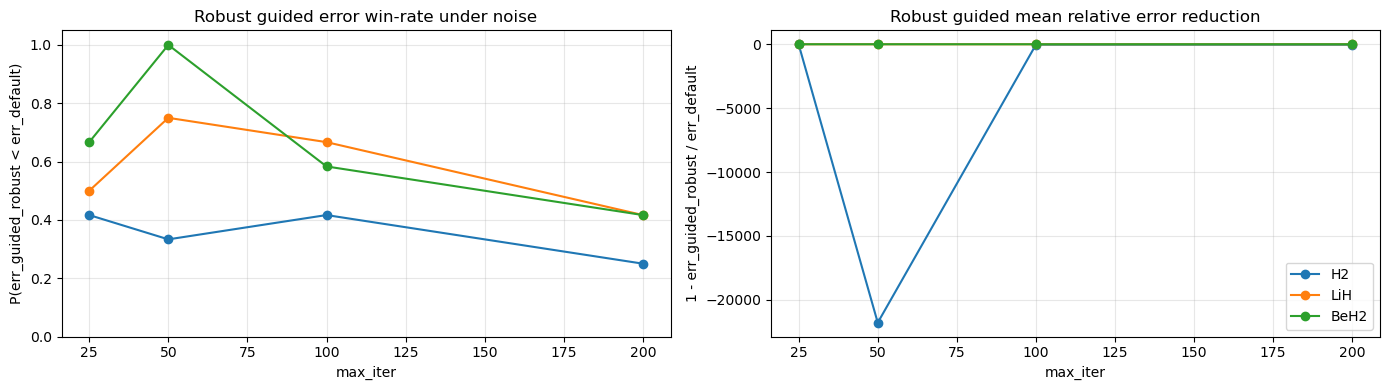

In [18]:
# Robust guided (noise-aware): averaged probes + confidence threshold + damped step + fallback.
import json
import hashlib
from pathlib import Path

ROBUST_QUICK_MODE = False
if ROBUST_QUICK_MODE:
    ROBUST_DISTANCE_LIMIT = {"H2": 2, "LiH": 2, "BeH2": 1}
    ROBUST_ITER_GRID = [25, 50, 100]
    ROBUST_REPEATS = 2
else:
    ROBUST_DISTANCE_LIMIT = dict(NOISE_DISTANCE_LIMIT)
    ROBUST_ITER_GRID = list(NOISE_ITER_GRID)
    ROBUST_REPEATS = int(NOISE_REPEATS)

ROBUST_PROBE_REPEATS = 3
ROBUST_MIN_AMPLITUDE = 1e-3
ROBUST_ALPHA = 0.35


def _robust_hash(obj: dict, length: int = 12) -> str:
    s = json.dumps(obj, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(s.encode("utf-8")).hexdigest()[:length]


def _robust_cache_path() -> Path:
    cache_dir = get_project_root() / "data" / "noise_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    key = {
        "iter_grid": ROBUST_ITER_GRID,
        "repeats": ROBUST_REPEATS,
        "distance_limit": ROBUST_DISTANCE_LIMIT,
        "probe_repeats": ROBUST_PROBE_REPEATS,
        "min_amp": ROBUST_MIN_AMPLITUDE,
        "alpha": ROBUST_ALPHA,
        "shots": NOISE_SHOTS,
        "p1": NOISE_P1,
        "p2": NOISE_P2,
        "readout": NOISE_READOUT,
        "seed": P0_SEED,
        "ansatz": P0_ANSATZ,
    }
    return cache_dir / f"noisy_guided_robust_{_robust_hash(key)}.csv"


def _guided_point_noisy_robust(ansatz, qubit_op, const_energy, p_center, estimator):
    # Use repeated probes to reduce shot noise impact on (a1, b1),
    # then trust the update only if harmonic amplitude is above threshold.
    n_params = ansatz.num_parameters
    direction = np.eye(n_params)[0]
    probe_thetas = [0.0, np.pi / 2.0, -np.pi / 2.0]

    y_probe_mean = []
    for t in probe_thetas:
        vals = []
        for _ in range(int(ROBUST_PROBE_REPEATS)):
            p = _wrap_pi(np.asarray(p_center, dtype=float) + float(t) * direction)
            vals.append(
                _eval_energy_estimator(
                    estimator=estimator,
                    ansatz=ansatz,
                    qubit_op=qubit_op,
                    const_energy=const_energy,
                    params=p,
                )
            )
        y_probe_mean.append(float(np.mean(vals)))

    f0, f_p, f_m = map(float, y_probe_mean)
    a0 = 0.5 * (f_p + f_m)
    b1 = 0.5 * (f_p - f_m)
    a1 = f0 - a0
    amp = float(np.hypot(a1, b1))

    probe_cost = len(probe_thetas) * int(ROBUST_PROBE_REPEATS)
    if amp < float(ROBUST_MIN_AMPLITUDE):
        return np.asarray(p_center, dtype=float), probe_cost, amp, False

    theta_star = float(np.arctan2(b1, a1) + np.pi)
    p_guided = _wrap_pi(np.asarray(p_center, dtype=float) + float(ROBUST_ALPHA) * theta_star * direction)
    return p_guided, probe_cost, amp, True


def _robust_row_key(row: dict):
    return (
        int(row["max_iter"]),
        str(row["system"]),
        round(float(row["distance"]), 10),
        int(row["repeat"]),
        str(row["mode"]),
    )


robust_cache_path = _robust_cache_path()
if robust_cache_path.exists():
    robust_cached_df = pd.read_csv(robust_cache_path)
    robust_rows = robust_cached_df.to_dict("records")
    print(f"Loaded robust guided cache: {robust_cache_path.name} ({len(robust_rows)} rows)")
else:
    robust_rows = []

robust_cached_keys = {_robust_row_key(r) for r in robust_rows}
robust_hits = 0
robust_misses = 0
robust_guided_used = 0
robust_fallback_used = 0

n_instances_robust = 0
for system_name, cfg in SYSTEMS.items():
    n_instances_robust += len(cfg["distances"][: ROBUST_DISTANCE_LIMIT.get(system_name, len(cfg["distances"]))])

n_total_runs_robust = len(ROBUST_ITER_GRID) * n_instances_robust * ROBUST_REPEATS * 2
print(f"Planned robust benchmark runs: {n_total_runs_robust}")

t0_robust = time.perf_counter()
new_run_idx = 0

for max_iter in ROBUST_ITER_GRID:
    for system_name, cfg in SYSTEMS.items():
        distances = cfg["distances"][: ROBUST_DISTANCE_LIMIT.get(system_name, len(cfg["distances"]))]

        for d in distances:
            d = float(d)
            _, qubit_op, const_energy = _build_qubit_instance(cfg, d)

            ansatz_raw = build_ansatz(
                name=P0_ANSATZ["name"],
                num_qubits=qubit_op.num_qubits,
                reps=P0_ANSATZ["reps"],
            )
            if ansatz_raw.num_parameters == 0:
                continue
            ansatz = _to_backend_circuit(ansatz_raw)

            exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
            exact_total = float(np.real(exact.eigenvalue) + const_energy)

            for rep in range(ROBUST_REPEATS):
                seed = int(P0_SEED + 5000 + 1000 * max_iter + 100 * rep + 7)
                p0 = np.random.default_rng(seed).uniform(-np.pi, np.pi, size=ansatz.num_parameters)

                est_default = _make_noisy_estimator(seed, noise_model)
                est_robust = _make_noisy_estimator(seed, noise_model)

                p_robust, robust_probe_cost, robust_amp, guided_used = _guided_point_noisy_robust(
                    ansatz=ansatz,
                    qubit_op=qubit_op,
                    const_energy=const_energy,
                    p_center=p0,
                    estimator=est_robust,
                )

                modes = [
                    ("default", p0, est_default, 0, 0.0, None),
                    (
                        "guided_fourier_robust",
                        p_robust,
                        est_robust,
                        int(robust_probe_cost),
                        float(robust_amp),
                        bool(guided_used),
                    ),
                ]

                for mode, init_point, estimator, guide_cost, amp, was_guided in modes:
                    key = (int(max_iter), str(system_name), round(float(d), 10), int(rep), str(mode))
                    if key in robust_cached_keys:
                        robust_hits += 1
                        continue
                    robust_misses += 1

                    optimizer = get_optimizer("cobyla", max_iter=int(max_iter))
                    res = run_vqe(
                        qubit_op=qubit_op,
                        ansatz=ansatz,
                        optimizer=optimizer,
                        estimator=estimator,
                        initial_point=np.asarray(init_point, dtype=float),
                        constant_energy=const_energy,
                        seed=seed,
                    )
                    new_run_idx += 1
                    if new_run_idx % 20 == 0:
                        print(f"progress (robust new runs): {new_run_idx}")

                    if not res.get("success", False):
                        continue

                    if mode == "guided_fourier_robust":
                        if was_guided:
                            robust_guided_used += 1
                        else:
                            robust_fallback_used += 1

                    row = {
                        "max_iter": int(max_iter),
                        "system": system_name,
                        "distance": d,
                        "repeat": int(rep),
                        "mode": mode,
                        "eval_count": int(res.get("eval_count", 0)),
                        "guide_cost": int(guide_cost),
                        "total_cost": float(res.get("eval_count", 0) + guide_cost),
                        "energy": float(res["energy"]),
                        "exact_total": exact_total,
                        "abs_error_vs_fci": float(abs(float(res["energy"]) - exact_total)),
                        "robust_amp": float(amp),
                        "robust_guided_used": was_guided,
                    }
                    robust_rows.append(row)
                    robust_cached_keys.add(_robust_row_key(row))

print(f"Robust benchmark loop finished in {time.perf_counter() - t0_robust:.1f} s")
print(
    f"Cache summary (robust): hits={robust_hits}, misses={robust_misses}, total_rows={len(robust_rows)}"
)
print(
    f"Robust guided strategy usage (new runs): guided={robust_guided_used}, fallback_default={robust_fallback_used}"
)

robust_df = pd.DataFrame(robust_rows)
if len(robust_df) == 0:
    raise RuntimeError("No rows available in robust benchmark.")

robust_df = robust_df.drop_duplicates(
    subset=["max_iter", "system", "distance", "repeat", "mode"],
    keep="last",
).sort_values(["max_iter", "system", "distance", "repeat", "mode"])
robust_df.to_csv(robust_cache_path, index=False)
print(f"Saved robust guided cache: {robust_cache_path} ({len(robust_df)} rows)")

display(robust_df.head(12))

robust_pair = robust_df.pivot_table(
    index=["max_iter", "system", "distance", "repeat"],
    columns="mode",
    values=["abs_error_vs_fci", "total_cost"],
    aggfunc="first",
).dropna().reset_index()

robust_pair.columns = [
    "max_iter",
    "system",
    "distance",
    "repeat",
    "err_default",
    "err_guided_robust",
    "cost_default",
    "cost_guided_robust",
]

robust_pair["guided_better_error"] = robust_pair["err_guided_robust"] < robust_pair["err_default"]
robust_pair["error_reduction_frac"] = 1.0 - (
    robust_pair["err_guided_robust"] / (robust_pair["err_default"] + 1e-16)
)
robust_pair["cost_delta"] = robust_pair["cost_guided_robust"] - robust_pair["cost_default"]

robust_summary = (
    robust_pair.groupby(["max_iter", "system"], as_index=False)
    .agg(
        guided_win_rate_error=("guided_better_error", "mean"),
        mean_error_reduction_frac=("error_reduction_frac", "mean"),
        mean_cost_delta=("cost_delta", "mean"),
    )
    .sort_values(["system", "max_iter"])
)
display(robust_summary.round(6))

fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
for system_name in SYSTEMS.keys():
    sub = robust_summary[robust_summary["system"] == system_name].sort_values("max_iter")
    if len(sub) == 0:
        continue
    ax[0].plot(sub["max_iter"], sub["guided_win_rate_error"], marker="o", label=system_name)
    ax[1].plot(sub["max_iter"], sub["mean_error_reduction_frac"], marker="o", label=system_name)

ax[0].set_title("Robust guided error win-rate under noise")
ax[0].set_xlabel("max_iter")
ax[0].set_ylabel("P(err_guided_robust < err_default)")
ax[0].set_ylim(0.0, 1.05)
ax[0].grid(alpha=0.3)

ax[1].set_title("Robust guided mean relative error reduction")
ax[1].set_xlabel("max_iter")
ax[1].set_ylabel("1 - err_guided_robust / err_default")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

,max_iter,system,guided_win_rate_error,mean_abs_error_gain,median_abs_error_gain,mean_relative_gain_stable,median_relative_gain_stable,mean_cost_delta
0,25,BeH2,0.666667,7.442877e-02,3.776425e-02,0.124905,0.217163,9.000000
3,50,BeH2,1.000000,2.763839e-01,2.297310e-01,0.635074,0.791635,9.000000
6,100,BeH2,0.583333,-6.571498e-02,5.483350e-03,-0.693837,0.088538,9.000000
9,200,BeH2,0.416667,-1.906760e-03,-1.717590e-03,-0.040696,-0.030170,9.000000
1,25,H2,0.416667,-2.000000e-07,-3.000000e-08,-0.092678,-0.032931,9.000000
4,50,H2,0.333333,-0.000000e+00,-0.000000e+00,-0.000203,-0.000225,8.333333
7,100,H2,0.416667,-0.000000e+00,-0.000000e+00,-0.000100,-0.000038,8.750000
10,200,H2,0.250000,-0.000000e+00,-0.000000e+00,-0.000599,-0.000304,9.666667
2,25,LiH,0.500000,6.490650e-03,-1.345140e-03,-0.045695,-0.037948,9.000000
5,50,LiH,0.750000,3.988290e-03,2.882350e-03,0.077983,0.068992,9.000000


,system,overall_win_rate,overall_median_abs_error_gain,overall_median_relative_gain_stable,overall_mean_cost_delta
0,BeH2,0.666667,0.011835,0.137212,9.0000
1,H2,0.354167,-0.000000,-0.000225,8.9375
2,LiH,0.583333,0.000467,0.023493,9.0000


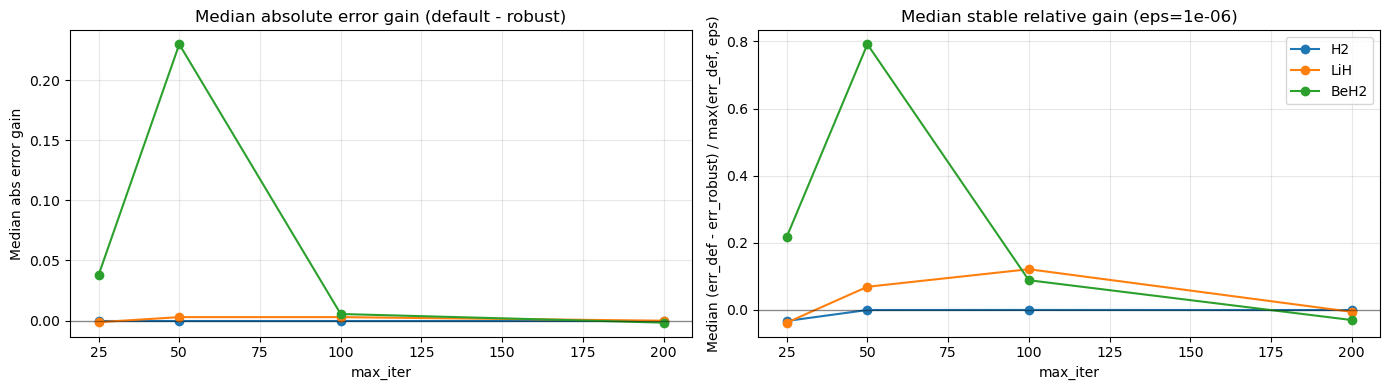

In [19]:
# Stable report for noisy robust-guided comparison.
# Uses absolute gain and denominator floor to avoid relative-metric blowups (e.g., H2 near-zero baseline error).
REL_EPS = 1e-6

if "robust_df" not in globals():
    raise RuntimeError("Run the robust guided benchmark cell first (robust_df is required).")

stable_pair = robust_df.pivot_table(
    index=["max_iter", "system", "distance", "repeat"],
    columns="mode",
    values=["abs_error_vs_fci", "total_cost"],
    aggfunc="first",
).dropna().reset_index()

stable_pair.columns = [
    "max_iter",
    "system",
    "distance",
    "repeat",
    "err_default",
    "err_guided_robust",
    "cost_default",
    "cost_guided_robust",
]

stable_pair["abs_error_gain"] = stable_pair["err_default"] - stable_pair["err_guided_robust"]
stable_pair["relative_gain_stable"] = stable_pair["abs_error_gain"] / (
    np.maximum(stable_pair["err_default"], REL_EPS)
)
stable_pair["guided_better_error"] = stable_pair["abs_error_gain"] > 0.0
stable_pair["cost_delta"] = stable_pair["cost_guided_robust"] - stable_pair["cost_default"]

stable_summary = (
    stable_pair.groupby(["max_iter", "system"], as_index=False)
    .agg(
        guided_win_rate_error=("guided_better_error", "mean"),
        mean_abs_error_gain=("abs_error_gain", "mean"),
        median_abs_error_gain=("abs_error_gain", "median"),
        mean_relative_gain_stable=("relative_gain_stable", "mean"),
        median_relative_gain_stable=("relative_gain_stable", "median"),
        mean_cost_delta=("cost_delta", "mean"),
    )
    .sort_values(["system", "max_iter"])
)

display(stable_summary.round(8))

stable_system = (
    stable_pair.groupby(["system"], as_index=False)
    .agg(
        overall_win_rate=("guided_better_error", "mean"),
        overall_median_abs_error_gain=("abs_error_gain", "median"),
        overall_median_relative_gain_stable=("relative_gain_stable", "median"),
        overall_mean_cost_delta=("cost_delta", "mean"),
    )
    .sort_values("system")
)

display(stable_system.round(8))

fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
for system_name in SYSTEMS.keys():
    sub = stable_summary[stable_summary["system"] == system_name].sort_values("max_iter")
    if len(sub) == 0:
        continue
    ax[0].plot(sub["max_iter"], sub["median_abs_error_gain"], marker="o", label=system_name)
    ax[1].plot(sub["max_iter"], sub["median_relative_gain_stable"], marker="o", label=system_name)

ax[0].axhline(0.0, color="k", lw=1, alpha=0.4)
ax[0].set_title("Median absolute error gain (default - robust)")
ax[0].set_xlabel("max_iter")
ax[0].set_ylabel("Median abs error gain")
ax[0].grid(alpha=0.3)

ax[1].axhline(0.0, color="k", lw=1, alpha=0.4)
ax[1].set_title(f"Median stable relative gain (eps={REL_EPS:g})")
ax[1].set_xlabel("max_iter")
ax[1].set_ylabel("Median (err_def - err_robust) / max(err_def, eps)")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

## Dissociation curves with noise vs full-space FCI (no active space)

This block rebuilds each Hamiltonian in full space (no active-space truncation), computes exact qubit reference, and compares noisy VQE curves (default vs guided sweep).

Loaded full-space noisy cache: fullspace_noisy_1657b9f3f653.csv (51 rows)
Cache summary (full-space): hits=34, misses=0, new_rows=0, fci_rows_added=0, total_rows=51
Saved full-space noisy cache: /Users/fabio/workspace/projects/PIBIC-FACEPE-2025-yann/pibic-yann-2025/códigos-yann/vqe-quantum-simulation/data/noise_cache/fullspace_noisy_1657b9f3f653.csv (51 rows)


,system,distance,repeat,mode,energy,total_cost,exact_fullspace_fci,abs_error_vs_fci
0,BeH2,0.500000,0,default,-9.488570,60.0,-13.689960,4.201390
1,BeH2,0.500000,0,fci_fullspace,-13.689960,0.0,-13.689960,0.000000
2,BeH2,0.500000,0,guided_fourier_arctan,-9.356997,63.0,-13.689960,4.332964
3,BeH2,0.653846,0,default,-11.920276,60.0,-14.680938,2.760662
4,BeH2,0.653846,0,fci_fullspace,-14.680938,0.0,-14.680938,0.000000
5,BeH2,0.653846,0,guided_fourier_arctan,-11.622042,63.0,-14.680938,3.058896
6,BeH2,0.807692,0,default,-12.150932,60.0,-15.190878,3.039945
7,BeH2,0.807692,0,fci_fullspace,-15.190878,0.0,-15.190878,0.000000
8,BeH2,0.807692,0,guided_fourier_arctan,-11.966198,63.0,-15.190878,3.224680
9,BeH2,0.961538,0,default,-12.745938,60.0,-15.443492,2.697554


,system,distance,mode,mean_energy,mean_abs_error_vs_fci
0,BeH2,0.500000,default,-9.488570,4.201390e+00
1,BeH2,0.500000,fci_fullspace,-13.689960,0.000000e+00
2,BeH2,0.500000,guided_fourier_arctan,-9.356997,4.332964e+00
3,BeH2,0.653846,default,-11.920276,2.760662e+00
4,BeH2,0.653846,fci_fullspace,-14.680938,0.000000e+00
5,BeH2,0.653846,guided_fourier_arctan,-11.622042,3.058896e+00
6,BeH2,0.807692,default,-12.150932,3.039945e+00
7,BeH2,0.807692,fci_fullspace,-15.190878,0.000000e+00
8,BeH2,0.807692,guided_fourier_arctan,-11.966198,3.224680e+00
9,BeH2,0.961538,default,-12.745938,2.697554e+00


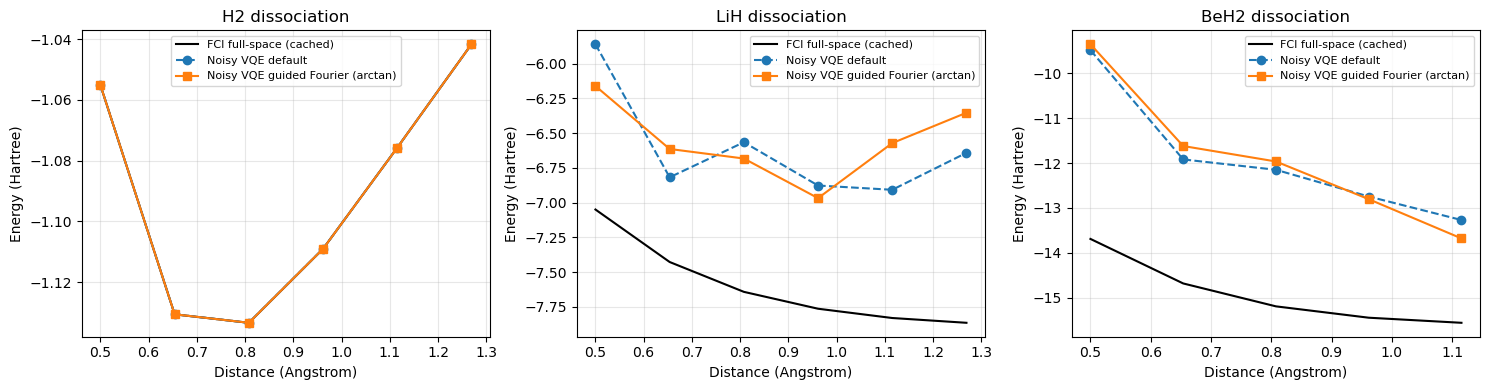

,system,mode,mean_abs_error_vs_fci
0,BeH2,default,2.997445e+00
1,BeH2,guided_fourier_arctan,3.026608e+00
2,H2,default,5.002037e-10
3,H2,guided_fourier_arctan,1.332268e-15
4,LiH,default,9.841676e-01
5,LiH,guided_fourier_arctan,1.037437e+00


In [20]:
# Full-space dissociation curves: noisy VQE vs cached full-space FCI reference,
# using Fourier-guided initialization via analytic arctan formula (3 probes).
import json
import hashlib
from pathlib import Path

from src.vqe.hamiltonian import build_electronic_problem
from src.data.cache import cache_fci
from src.utils.paths import get_project_root

FULLSPACE_QUICK_MODE = False
if FULLSPACE_QUICK_MODE:
    FULLSPACE_DISTANCE_LIMIT = {"H2": 4, "LiH": 4, "BeH2": 3}
    FULLSPACE_MAX_ITER = 40
else:
    FULLSPACE_DISTANCE_LIMIT = {"H2": 6, "LiH": 6, "BeH2": 5}
    FULLSPACE_MAX_ITER = 60

FULLSPACE_REPEATS = 1


def _stable_hash(obj: dict, length: int = 12) -> str:
    s = json.dumps(obj, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(s.encode("utf-8")).hexdigest()[:length]


def _fullspace_cache_path() -> Path:
    cache_dir = get_project_root() / "data" / "noise_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)

    key = {
        "ansatz": P0_ANSATZ,
        "distance_limit": FULLSPACE_DISTANCE_LIMIT,
        "max_iter": FULLSPACE_MAX_ITER,
        "repeats": FULLSPACE_REPEATS,
        "shots": NOISE_SHOTS,
        "p1": NOISE_P1,
        "p2": NOISE_P2,
        "readout": NOISE_READOUT,
        "seed": P0_SEED,
        "systems": {k: {"basis": v["basis"], "mapper": v["mapper"], "z2": v["z2"]} for k, v in SYSTEMS.items()},
    }
    return cache_dir / f"fullspace_noisy_{_stable_hash(key)}.csv"


def _build_qubit_instance_fullspace(cfg: dict, d: float):
    atom = cfg["geom"](float(d))

    problem = build_electronic_problem(
        atom_string=atom,
        basis=cfg["basis"],
        active_space=None,
        active_orbitals=None,
        homo_lumo_window=0,
        freeze_core=False,
    )
    ferm_op, const_energy = build_electronic_hamiltonian(
        atom_string=atom,
        basis=cfg["basis"],
        active_space=None,
        active_orbitals=None,
        homo_lumo_window=0,
        freeze_core=False,
    )
    qubit_op = build_qubit_hamiltonian(
        ferm_op,
        mapper=cfg["mapper"],
        z2symmetry_reduction=cfg["z2"],
        problem=problem,
        num_particles=problem.num_particles,
    ).simplify(atol=0.0)
    return problem, qubit_op, float(const_energy)


def _guided_point_fourier_arctan(ansatz, qubit_op, const_energy, p_center, estimator):
    # First-harmonic estimate from 3 probes and analytic minimizer:
    # theta* = atan2(b1, a1) + pi.
    n_params = ansatz.num_parameters
    direction = np.eye(n_params)[0]

    probe_thetas = [0.0, np.pi / 2.0, -np.pi / 2.0]
    y_probe = []
    for t in probe_thetas:
        p = _wrap_pi(np.asarray(p_center, dtype=float) + float(t) * direction)
        y_probe.append(
            _eval_energy_estimator(
                estimator=estimator,
                ansatz=ansatz,
                qubit_op=qubit_op,
                const_energy=const_energy,
                params=p,
            )
        )

    f0, f_p, f_m = map(float, y_probe)
    a0 = 0.5 * (f_p + f_m)
    b1 = 0.5 * (f_p - f_m)
    a1 = f0 - a0
    theta_star = float(np.arctan2(b1, a1) + np.pi)

    p_guided = _wrap_pi(np.asarray(p_center, dtype=float) + theta_star * direction)
    return p_guided, len(probe_thetas)


def _row_key(row: dict):
    return (
        str(row["system"]),
        round(float(row["distance"]), 10),
        int(row["repeat"]),
        str(row["mode"]),
    )


full_cache_path = _fullspace_cache_path()
if full_cache_path.exists():
    cached_full_df = pd.read_csv(full_cache_path)
    rows_full = cached_full_df.to_dict("records")
    print(f"Loaded full-space noisy cache: {full_cache_path.name} ({len(rows_full)} rows)")
else:
    rows_full = []
cached_keys = {_row_key(r) for r in rows_full}
initial_cached_rows = len(cached_keys)
cache_hits = 0
cache_misses = 0
fci_rows_added = 0

for system_name, cfg in SYSTEMS.items():
    distances = cfg["distances"][: FULLSPACE_DISTANCE_LIMIT.get(system_name, len(cfg["distances"]))]

    # FCI/CASCI molecular reference from persistent cache.
    fci_vals = cache_fci(
        molecule=system_name,
        geometry_fn=cfg["geom"],
        distances=np.asarray(distances, dtype=float),
        basis=cfg["basis"],
        active_space=None,
        active_orbitals=None,
        homo_lumo_window=0,
        freeze_core=0,
        overwrite=False,
        verbose=False,
    )
    fci_by_d = {round(float(d), 10): float(e) for d, e in zip(np.asarray(distances, dtype=float), fci_vals)}

    for d in distances:
        d = float(d)
        d_key = round(d, 10)
        try:
            _, qubit_op, const_energy = _build_qubit_instance_fullspace(cfg, d)

            # Prefer cached molecular FCI reference; fallback to exact qubit diagonalization if needed.
            exact_total = fci_by_d.get(d_key, np.nan)
            if not np.isfinite(exact_total):
                exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
                exact_total = float(np.real(exact.eigenvalue) + const_energy)

            ansatz_raw = build_ansatz(
                name=P0_ANSATZ["name"],
                num_qubits=qubit_op.num_qubits,
                reps=P0_ANSATZ["reps"],
            )
            if ansatz_raw.num_parameters == 0:
                continue
            ansatz = _to_backend_circuit(ansatz_raw)

            for rep in range(FULLSPACE_REPEATS):
                seed = int(P0_SEED + 9000 + 100 * rep + int(1000 * d))
                p0 = np.random.default_rng(seed).uniform(-np.pi, np.pi, size=ansatz.num_parameters)

                est_default = _make_noisy_estimator(seed, noise_model)
                est_guided = _make_noisy_estimator(seed, noise_model)

                p_guided, c_guided = _guided_point_fourier_arctan(
                    ansatz=ansatz,
                    qubit_op=qubit_op,
                    const_energy=const_energy,
                    p_center=p0,
                    estimator=est_guided,
                )

                modes = [
                    ("default", p0, est_default, 0),
                    ("guided_fourier_arctan", p_guided, est_guided, int(c_guided)),
                ]

                for mode, init_point, estimator, guide_cost in modes:
                    key = (str(system_name), d_key, int(rep), str(mode))
                    if key in cached_keys:
                        cache_hits += 1
                        continue
                    cache_misses += 1

                    optimizer = get_optimizer("cobyla", max_iter=int(FULLSPACE_MAX_ITER))
                    res = run_vqe(
                        qubit_op=qubit_op,
                        ansatz=ansatz,
                        optimizer=optimizer,
                        estimator=estimator,
                        initial_point=np.asarray(init_point, dtype=float),
                        constant_energy=const_energy,
                        seed=seed,
                    )
                    if not res.get("success", False):
                        continue

                    row = {
                        "system": system_name,
                        "distance": d,
                        "repeat": int(rep),
                        "mode": mode,
                        "energy": float(res["energy"]),
                        "total_cost": float(res.get("eval_count", 0) + guide_cost),
                        "exact_fullspace_fci": exact_total,
                        "abs_error_vs_fci": float(abs(float(res["energy"]) - exact_total)),
                    }
                    rows_full.append(row)
                    cached_keys.add(_row_key(row))

                key_fci = (str(system_name), d_key, int(rep), "fci_fullspace")
                if key_fci not in cached_keys:
                    row_fci = {
                        "system": system_name,
                        "distance": d,
                        "repeat": int(rep),
                        "mode": "fci_fullspace",
                        "energy": exact_total,
                        "total_cost": 0.0,
                        "exact_fullspace_fci": exact_total,
                        "abs_error_vs_fci": 0.0,
                    }
                    rows_full.append(row_fci)
                    cached_keys.add(_row_key(row_fci))
                    fci_rows_added += 1

        except Exception as exc:
            print(f"Skipping {system_name} d={d:.3f}: {exc}")

new_rows_added = len(rows_full) - initial_cached_rows
print(
    f"Cache summary (full-space): hits={cache_hits}, misses={cache_misses}, "
    f"new_rows={new_rows_added}, fci_rows_added={fci_rows_added}, total_rows={len(rows_full)}"
)

full_df = pd.DataFrame(rows_full)
if len(full_df) == 0:
    raise RuntimeError("No rows available in full-space benchmark (cache empty and no new runs).")

full_df = full_df.drop_duplicates(
    subset=["system", "distance", "repeat", "mode"],
    keep="last",
).sort_values(["system", "distance", "repeat", "mode"])
full_df.to_csv(full_cache_path, index=False)
print(f"Saved full-space noisy cache: {full_cache_path} ({len(full_df)} rows)")

display(full_df.head(12))

curve_df = (
    full_df.groupby(["system", "distance", "mode"], as_index=False)
    .agg(
        mean_energy=("energy", "mean"),
        mean_abs_error_vs_fci=("abs_error_vs_fci", "mean"),
    )
    .sort_values(["system", "distance", "mode"])
)
display(curve_df.head(20))

systems_present = [s for s in SYSTEMS.keys() if s in curve_df["system"].unique()]
fig, axes = plt.subplots(1, len(systems_present), figsize=(5 * max(1, len(systems_present)), 4), sharey=False)
if len(systems_present) == 1:
    axes = [axes]

for ax, system_name in zip(axes, systems_present):
    sub = curve_df[curve_df["system"] == system_name].sort_values("distance")

    for mode, style in [
        ("fci_fullspace", "k-"),
        ("default", "--o"),
        ("guided_fourier_arctan", "-s"),
    ]:
        m = sub[sub["mode"] == mode].sort_values("distance")
        if len(m) == 0:
            continue
        label = {
            "fci_fullspace": "FCI full-space (cached)",
            "default": "Noisy VQE default",
            "guided_fourier_arctan": "Noisy VQE guided Fourier (arctan)",
        }[mode]
        ax.plot(m["distance"], m["mean_energy"], style, label=label)

    ax.set_title(f"{system_name} dissociation")
    ax.set_xlabel("Distance (Angstrom)")
    ax.set_ylabel("Energy (Hartree)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

full_err_summary = (
    curve_df[curve_df["mode"].isin(["default", "guided_fourier_arctan"])]
    .groupby(["system", "mode"], as_index=False)
    .agg(mean_abs_error_vs_fci=("mean_abs_error_vs_fci", "mean"))
    .sort_values(["system", "mode"])
)
display(full_err_summary)